
>>> Ra-222   (Z_hija=86, A_hija=218, Q=6.678 MeV, beta2=0.04, beta4=0.029, beta_nl=0.216 fm)
  [FT] densidad deformada de la hija (L = 0, 2, 4)...
  [V]  potenciales multipolares nuclear y Coulomb...
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (tiempo total: 30.1 s)

Ra-222   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: 'after')
Modelo          phi   lambda       r1       r2       r3            P          N      t1/2 (s)
----------------------------------------------------------------------------------------------------------------------
DF              0.0   1.9425    0.091    9.024   37.028    2.204e-22     0.3302     1.178e+00
DF              5.0   1.9443    0.091    9.018   37.028    2.160e-22     0.3306     1.201e+00
DF             10.0   1.9496    0.091    9.001   37.027    2.037e-22     0.3318     1.268e+00
DF             15.0   1.9580    0.091    8.975   37.026    1.855e-22     0.3338     1.385e+00
DF             20.0   1.96

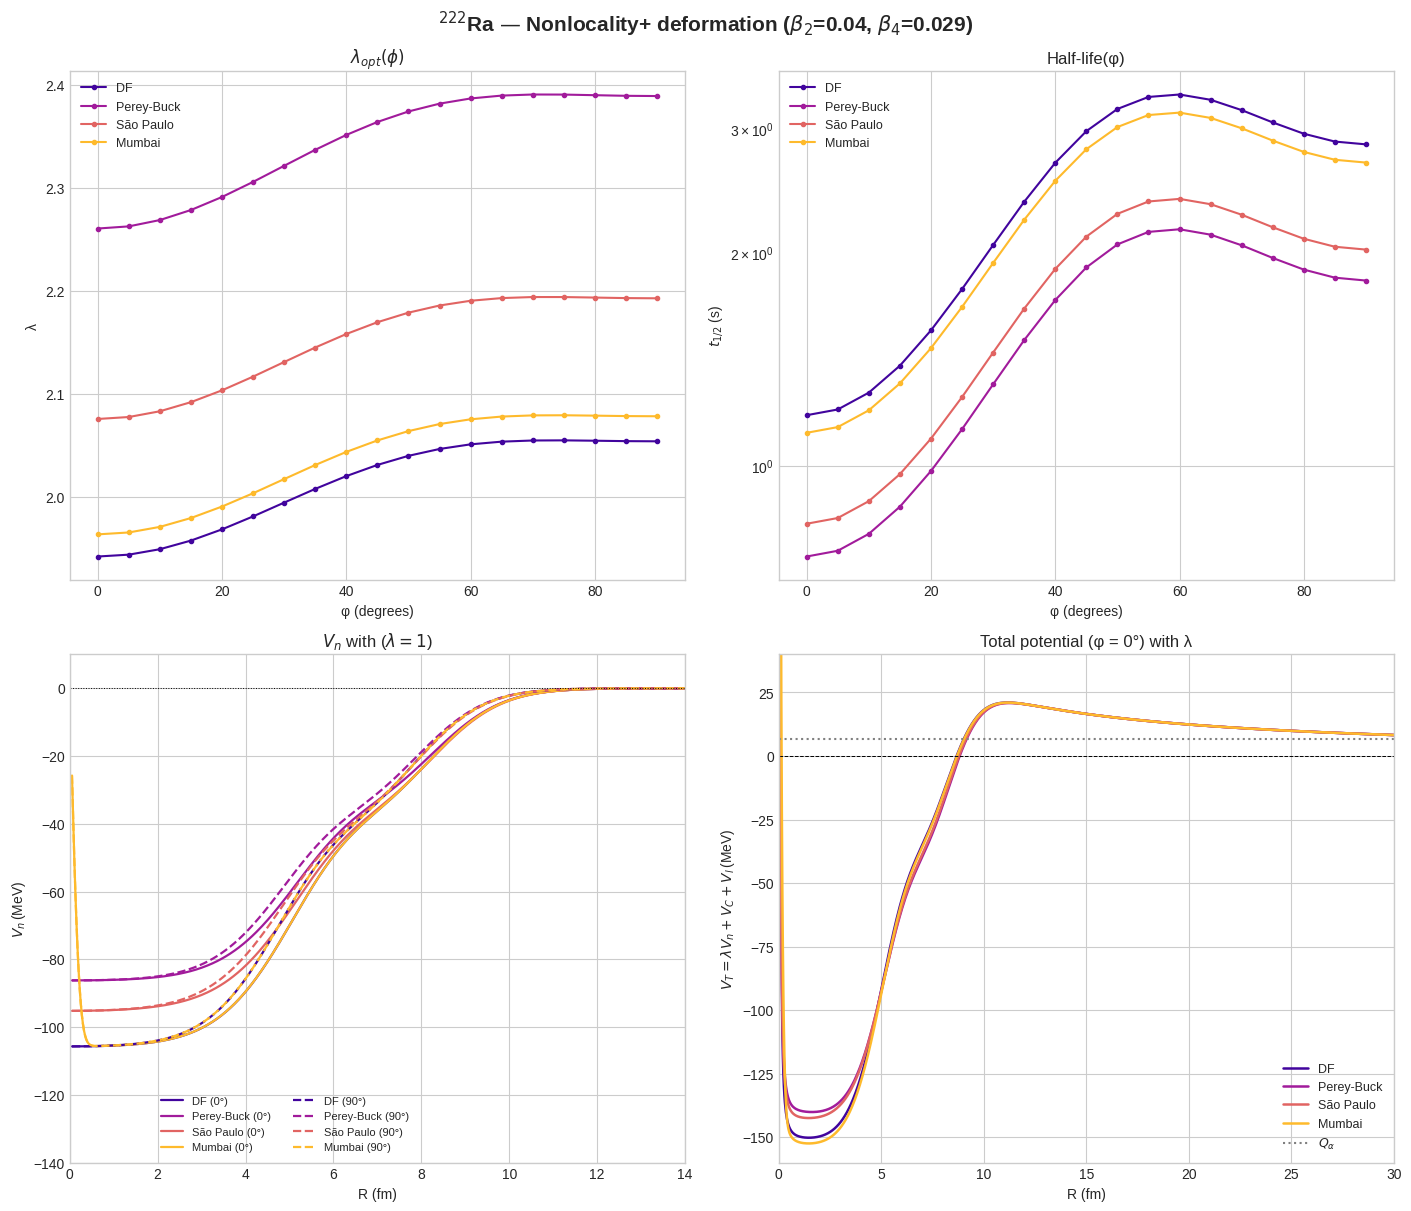

In [1]:
# -*- coding: utf-8 -*-
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa
═══════════════════════════════════════════════════════════════════════════════

 Alfa   : esférica (densidad gaussiana)
 Hija   : Fermi deformada  ->  R(theta), a(theta)  con Y20, Y40
 Salida : lambda(phi), puntos de retorno, P, N, tau(phi) para los 4 modelos
          + vida media promediada angularmente

 NOTAS FÍSICAS IMPORTANTES (no es "solo sintaxis"):
 ------------------------------------------------------------------
 (1) Perey-Buck y São Paulo son transformaciones NO LINEALES en V.
     => se aplican al potencial nuclear TOTAL a phi fijo,
        NUNCA multipolo por multipolo.
 (2) Mumbai es LINEAL en V  => Mumbai(lam*V) = lam*Mumbai(V).
     Por eso para Mumbai da exactamente igual renormalizar antes o después.
 (3) São Paulo usa V_Coulomb en la exponencial: aquí se usa el
     V_Coulomb(R, phi) de la MISMA orientación.

 CAMBIOS NUMÉRICOS respecto a tus dos códigos:
 ------------------------------------------------------------------
 * j_L: se usa scipy.special.spherical_jn. Tus j2_f/j4_f tenían
   términos 105/x^5 que se rompen para k*r ~ 1e-5 (cancelación
   catastrófica). Ese era un bug latente en el código deformado.
 * theta: cuadratura Gauss-Legendre en u = cos(theta) (64 nodos)
   en vez de Simpson en theta. Más exacta y más barata.
 * Perey-Buck / São Paulo: se resuelven con la función W de Lambert
   (solución EXACTA y vectorizada) en vez de brentq punto por punto.
   Es la misma raíz física que daba tu brentq (rama principal, la que
   tiende a U -> U_bare cuando beta_nl -> 0).
 * Mumbai: se explota que la grilla R es uniforme  => el kernel es
   Toeplitz/Hankel y V((Ri+Rj)/2) vive en una semi-grilla.
   Se reduce de O(N^2) evaluaciones de spline a O(N) + gathers.
 * lambda: barrido grueso + brentq (en vez de 3000 puntos de barrido).
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════
NUCLEUS = dict(name="Ra-222", Z_d=86, A_d=218, Q=6.678, G=22,
               beta2=0.04, beta4=0.029)

# "after"  -> lambda multiplica el potencial YA transformado  (= tu código 1)
# "before" -> lambda renormaliza el folding desnudo y LUEGO se hace no-local
LAMBDA_MODE = "after"

MAKE_PLOTS = True

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0   # dR ~ 0.025 fm  (necesario para Mumbai)
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0           # densidad de la hija
N_U               = 64                  # nodos Gauss-Legendre en cos(theta)
N_PHI             = 19                  # orientaciones en [0, pi/2] (impar!)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
Z_alpha, A_alpha = 2, 4
e2       = 1.44
a_0      = 0.54
alpha_g  = 0.7024                # ancho gaussiano de la alfa
x_g      = 7999 / 4              # interacción NN (M3Y-like, forma Yukawa doble)
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22       # MeV*s
m_n      = 931.494
L        = 0                     # momento angular del alfa
beta_nl  = 0.2160                  # RANGO DE NO-LOCALIDAD (Perey-Buck / Mumbai)

name  = NUCLEUS["name"]
Z_d   = NUCLEUS["Z_d"]
A_d   = NUCLEUS["A_d"]
Q     = NUCLEUS["Q"]
G     = NUCLEUS["G"]
beta2 = NUCLEUS["beta2"]
beta4 = NUCLEUS["beta4"]

R_0  = 1.07 * A_d ** (1 / 3)
mu   = (A_d * A_alpha) / (A_d + A_alpha) * m_n
B_qn = (G - L + 1) * (np.pi / 2)          # regla de Bohr-Sommerfeld
zpb  = (mu * beta_nl ** 2) / (2 * hbarc ** 2)
r3_C = (Z_alpha * Z_d * e2) / Q           # radio de Coulomb puro (referencia)


# ═════════════════════════════════════════════════════════════════════════════
#  GEOMETRÍA DEFORMADA DE LA HIJA
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def R_f_theta(th):
    return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))


def a_f_theta(th):
    a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
    c, s = np.cos(th), np.sin(th)
    gradR = (R_0 / R_f_theta(th)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)   # int_-1^1 du  == int sin(th) dth
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)

if dR > beta_nl / 4:
    print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {beta_nl} fm "
          f"(Mumbai será impreciso). Sube N_R.")


# ═════════════════════════════════════════════════════════════════════════════
#  DENSIDAD DEFORMADA Y SUS TRANSFORMADAS DE FOURIER MULTIPOLARES
# ═════════════════════════════════════════════════════════════════════════════
Rf_u = R_f_theta(theta_gl)
af_u = a_f_theta(theta_gl)

# fermi[r, u]
fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

# Normalización:  int rho dV = 2*pi * int dr r^2 * int du fermi
I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
norm_N  = A_d / I_geo
norm_Cd = Z_d / I_geo


def fourier_rho2_L(Lm, norm, kchunk=64):
    """rho2_L(k) = 2pi * norm * int dr r^2 int du  j_L(kr) Y_L0(th) fermi(r,u)"""
    out = np.empty(N_K)
    W = w_gl * YLM[Lm](theta_gl)                     # (Nu,)
    r2f = (r ** 2)[:, None] * fermi                  # (Nr, Nu)
    for a0 in range(0, N_K, kchunk):
        kk = k[a0:a0 + kchunk]                       # (nk,)
        jl = spherical_jn(Lm, r[:, None] * kk[None, :])          # (Nr, nk)
        tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)   # (Nu, nk)
        out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
    return out


print(f"\n>>> {name}   (Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
      f"beta2={beta2}, beta4={beta4}, beta_nl={beta_nl} fm)")
t0 = time.time()
print("  [FT] densidad deformada de la hija (L = 0, 2, 4)...")
rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

# --- alfa (esférica, analítica) ----------------------------------------------
I_r1        = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k     = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn     = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc     = (Z_alpha / (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k


# ═════════════════════════════════════════════════════════════════════════════
#  POTENCIALES MULTIPOLARES  ->  V(R, phi)
# ═════════════════════════════════════════════════════════════════════════════
g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


print("  [V]  potenciales multipolares nuclear y Coulomb...")
pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}

V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


PL = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])          # (3, Nphi)

V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
             + V_NN_L[2][:, None] * PL[1][None, :]
             + V_NN_L[4][:, None] * PL[2][None, :])            # (NR, Nphi)

V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
             + V_C_L[2][:, None] * PL[1][None, :]
             + V_C_L[4][:, None] * PL[2][None, :])

V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)   # (NR,)


# ═════════════════════════════════════════════════════════════════════════════
#  NO-LOCALIDAD
# ═════════════════════════════════════════════════════════════════════════════
def _lambert_local(V_bare, E_eff):
    """
    Resuelve   U * exp(zpb * (E_eff - U)) = V_bare   en la rama física.
        t = -zpb*U  ->  t e^t = -zpb * V_bare * exp(-zpb*E_eff)
        U = -W0(arg)/zpb
    Reproduce exactamente la raíz que buscaba tu brentq(-350, 100).
    """
    arg = -zpb * V_bare * np.exp(-zpb * E_eff)
    w = lambertw(arg, k=0)
    U = -np.real(w) / zpb
    bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
    return np.where(bad, V_bare, U)          # fallback: potencial desnudo


def perey_buck(V_bare):
    """U * exp(zpb*(Q - U)) = V_bare"""
    return _lambert_local(V_bare, Q)


def sao_paulo(V_bare, V_C_col):
    """U * exp(zpb*(Q - V_C - U)) = V_bare"""
    return _lambert_local(V_bare, Q - V_C_col)


# --- Mumbai: kernel gaussiano no local, explotando grilla uniforme ------------
_i = np.arange(N_R)
_H = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)                 # semi-grilla
_K1 = np.exp(-((np.arange(-(N_R - 1), N_R) * dR) ** 2) / beta_nl ** 2)   # dep. de i-j
_K2 = np.exp(-((2 * R_MIN + np.arange(2 * N_R - 1) * dR) ** 2) / beta_nl ** 2)  # i+j


def mumbai(V_col, chunk=256):
    """
    V_M(R) = 1/(sqrt(pi) beta) * int dR' V((R+R')/2) *
             [ exp(-(R-R')^2/beta^2) - exp(-(R+R')^2/beta^2) ]
    """
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh = spl(_H)                                    # V en la semi-grilla
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii = _i[i0:i0 + chunk][:, None]
        s = ii + _i[None, :]                        # i+j
        d = ii - _i[None, :] + (N_R - 1)            # i-j desplazado
        ker = _K1[d] - _K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * beta_nl)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTRUCTOR DE POTENCIAL POR MODELO
# ═════════════════════════════════════════════════════════════════════════════
def make_builder(model, VNN_col, VC_col):
    """Devuelve  lam -> V_nuclear_local(R)  para la orientación dada."""
    if model == "DF":
        return lambda lam: lam * VNN_col

    if model == "Mumbai":                      # lineal: antes == después
        VM = mumbai(VNN_col)
        return lambda lam: lam * VM

    if model == "Perey-Buck":
        if LAMBDA_MODE == "after":
            U = perey_buck(VNN_col)
            return lambda lam: lam * U
        return lambda lam: perey_buck(lam * VNN_col)

    if model == "São Paulo":
        if LAMBDA_MODE == "after":
            U = sao_paulo(VNN_col, VC_col)
            return lambda lam: lam * U
        return lambda lam: sao_paulo(lam * VNN_col, VC_col)

    raise ValueError(model)


# ═════════════════════════════════════════════════════════════════════════════
#  BOHR-SOMMERFELD + WKB  PARA UNA ORIENTACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def _spline_and_roots(builder, lam, VC_col):
    V = builder(lam) + VC_col + V_cent
    s = InterpolatedUnivariateSpline(R, Q - V, k=3)
    rts = s.roots()
    if len(rts) < 3:
        return None
    return s, rts[0], rts[1], rts[2]


def action_inner(builder, lam, VC_col):
    out = _spline_and_roots(builder, lam, VC_col)
    if out is None:
        return None
    s, r1, r2, _ = out
    I = quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
             r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]
    return I


def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
    """Busca lambda tal que S_interior(lambda) = B, y devuelve todo lo demás."""
    grid = np.linspace(lam_lo, lam_hi, n_scan)
    f = []
    for lam in grid:
        I = action_inner(builder, lam, VC_col)
        f.append(np.nan if I is None else I - B_qn)
    f = np.array(f)

    lam_opt = None
    ok = np.isfinite(f)
    for a, b in zip(range(n_scan - 1), range(1, n_scan)):
        if ok[a] and ok[b] and f[a] * f[b] < 0:
            lam_opt = brentq(
                lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                grid[a], grid[b], xtol=1e-5)
            break
    if lam_opt is None:                       # no hubo cambio de signo
        if not ok.any():
            return None
        lam_opt = grid[np.nanargmin(np.abs(f))]

    out = _spline_and_roots(builder, lam_opt, VC_col)
    if out is None:
        return None
    s, r1, r2, r3 = out

    # V(r) - Q  =  -s(r)
    I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
               r2, r3, limit=200, points=[r2, r3], epsabs=1e-4, epsrel=1e-4)[0]
    I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
               r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]

    N_norm = 1.0 / I_f
    P = np.exp(-2 * I_G)
    Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
    tau = (hbar * np.log(2)) / Gamma
    return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                P=P, N=N_norm, Gamma=Gamma, tau=tau)


# ═════════════════════════════════════════════════════════════════════════════
#  LOOP PRINCIPAL:  4 modelos  x  N_PHI orientaciones
# ═════════════════════════════════════════════════════════════════════════════
MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]
resultados = {m: [] for m in MODELOS}

for m in MODELOS:
    print(f"  [WKB] {m} ...", end="", flush=True)
    for j in range(N_PHI):
        builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
        resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
    print(" ok")

print(f"  (tiempo total: {time.time() - t0:.1f} s)")


# ═════════════════════════════════════════════════════════════════════════════
#  PROMEDIO ANGULAR
#  El alfa se emite en todas las orientaciones -> se promedia el ANCHO:
#      <Gamma> = int_0^{pi/2} Gamma(phi) sin(phi) dphi / int_0^{pi/2} sin(phi) dphi
#      T_1/2   = hbar ln2 / <Gamma>
# ═════════════════════════════════════════════════════════════════════════════
w_phi = np.sin(phi)
den = simpson(w_phi, x=phi)


def promedio(res_list):
    g = np.array([np.nan if r is None else r["Gamma"] for r in res_list])
    good = np.isfinite(g)
    if not good.any():
        return None
    g = np.where(good, g, 0.0)
    G_avg = simpson(g * w_phi, x=phi) / den
    return G_avg, (hbar * np.log(2)) / G_avg


# ═════════════════════════════════════════════════════════════════════════════
#  TABLAS
# ═════════════════════════════════════════════════════════════════════════════
sep = "=" * 118
print("\n" + sep)
print(f"{name}   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: '{LAMBDA_MODE}')")
print(sep)
print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
      f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
print("-" * 118)
for m in MODELOS:
    for j, res in enumerate(resultados[m]):
        if res is None:
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {'--- sin solución ---':>60}")
            continue
        print(f"{m:<12} {np.degrees(phi[j]):6.1f} {res['lam']:8.4f} "
              f"{res['r1']:8.3f} {res['r2']:8.3f} {res['r3']:8.3f} "
              f"{res['P']:12.3e} {res['N']:10.4f} {res['tau']:13.3e}")
    print("-" * 118)

print("\n" + sep)
print(f"{name}   —  RESUMEN PROMEDIADO ANGULARMENTE       "
      f"(r3 Coulomb puro = {r3_C:.2f} fm)")
print(sep)
print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
      f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
print("-" * 118)
for m in MODELOS:
    lams = np.array([r["lam"] for r in resultados[m] if r is not None])
    t0d = resultados[m][0]
    t90 = resultados[m][-1]
    pr = promedio(resultados[m])
    print(f"{m:<12} {lams.mean():10.4f} "
          f"{(t0d['tau'] if t0d else np.nan):13.3e} "
          f"{(t90['tau'] if t90 else np.nan):13.3e} "
          f"{(pr[0] if pr else np.nan):15.3e} "
          f"{(pr[1] if pr else np.nan):18.3e}")
print(sep + "\n")




    # ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    fig.suptitle(rf"$^{{{A_d + 4}}}${name.split('-')[0]} — Nonlocality"
                 rf"+ deformation ($\beta_2$={beta2}, $\beta_4$={beta4})",
                 fontsize=15, fontweight='bold')

    for m in MODELOS:
        ph = np.degrees([phi[j] for j, r in enumerate(resultados[m]) if r])
        lm = [r["lam"] for r in resultados[m] if r]
        tt = [r["tau"] for r in resultados[m] if r]
        ax[0, 0].plot(ph, lm, '-o', ms=3, label=m, color=colors[m])
        ax[0, 1].semilogy(ph, tt, '-o', ms=3, label=m, color=colors[m])

    ax[0, 0].set(xlabel="φ (degrees)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
    ax[0, 1].set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)",
                 title="Half-life(φ)")
    for a in (ax[0, 0], ax[0, 1]):
        a.legend(frameon=False, fontsize=9)

    # potenciales nucleares locales-equivalentes en phi = 0 y 90
    for jj, ls, lbl in ((0, '-', '0°'), (N_PHI - 1, '--', '90°')):
        for m in MODELOS:
            bld = make_builder(m, V_Nuclear[:, jj], V_Coulomb[:, jj])
            ax[1, 0].plot(R, bld(1.0), ls, lw=1.6, color=colors[m],
                          label=f"{m} ({lbl})")
    ax[1, 0].set(xlabel="R (fm)", ylabel=r"$V_{n}\,$(MeV)", xlim=(0, 14), ylim=(-140, 10),
                 title=r"$V_{n}$ with ($\lambda=1$)")
    ax[1, 0].axhline(0, color='k', lw=0.7, ls=':')
    ax[1, 0].legend(fontsize=8, ncol=2, loc='lower center', bbox_to_anchor=(0.35, 0))

    # potencial total
    for m in MODELOS:
        res = resultados[m][0]
        if res is None:
            continue
        bld = make_builder(m, V_Nuclear[:, 0], V_Coulomb[:, 0])
        ax[1, 1].plot(R, bld(res["lam"]) + V_Coulomb[:, 0] + V_cent,
                      lw=1.8, color=colors[m], label=m)
    ax[1, 1].axhline(Q, color='gray', ls=':', lw=1.5, label=r"$Q_\alpha$")
    ax[1, 1].axhline(0, color='k', lw=0.7, ls='--')
    ax[1, 1].set(xlabel="R (fm)", ylabel=r"$V_{T}=λV_{n}+V_{C}+V_{l}\,$(MeV)", xlim=(0, 30), ylim=(-160, 40),
                 title="Total potential (φ = 0°) with λ")
    ax[1, 1].legend(fontsize=9, frameon=False)
    plt.savefig('222RA-nonloca-deformation.png')
    plt.show()


>>> Og-294   (Z_hija=116, A_hija=290, Q=11.87 MeV, beta2=0.072, beta4=-0.031, beta_nl=0.2154 fm)
  [FT] densidad deformada de la hija (L = 0, 2, 4)...
  [V]  potenciales multipolares nuclear y Coulomb...
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (tiempo total: 33.9 s)

Og-294   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: 'after')
Modelo          phi   lambda       r1       r2       r3            P          N      t1/2 (s)
----------------------------------------------------------------------------------------------------------------------
DF              0.0   1.9556    0.092    9.478   28.152    2.430e-17     0.3339     1.061e-05
DF              5.0   1.9554    0.092    9.480   28.151    2.456e-17     0.3337     1.051e-05
DF             10.0   1.9550    0.092    9.486   28.150    2.531e-17     0.3333     1.021e-05
DF             15.0   1.9547    0.092    9.493   28.147    2.646e-17     0.3326     9.787e-06
DF             20.0   

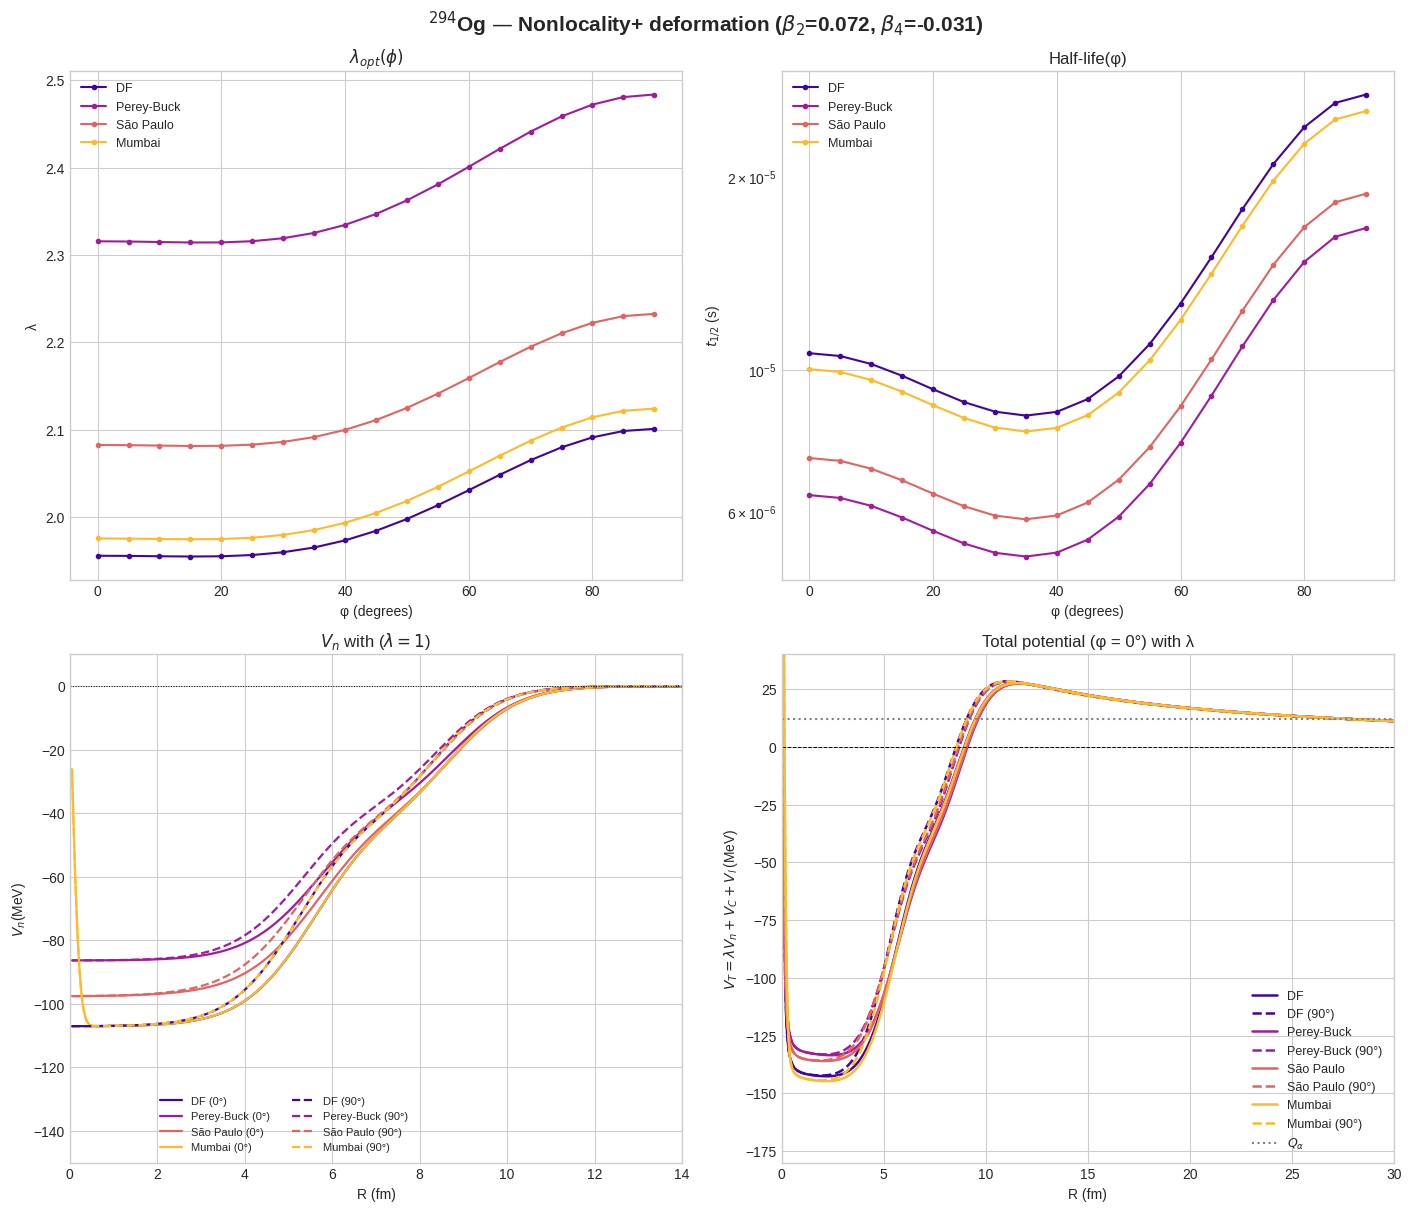

In [4]:
# -*- coding: utf-8 -*-
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa
═══════════════════════════════════════════════════════════════════════════════

 Alfa   : esférica (densidad gaussiana)
 Hija   : Fermi deformada  ->  R(theta), a(theta)  con Y20, Y40
 Salida : lambda(phi), puntos de retorno, P, N, tau(phi) para los 4 modelos
          + vida media promediada angularmente

 NOTAS FÍSICAS IMPORTANTES (no es "solo sintaxis"):
 ------------------------------------------------------------------
 (1) Perey-Buck y São Paulo son transformaciones NO LINEALES en V.
     => se aplican al potencial nuclear TOTAL a phi fijo,
        NUNCA multipolo por multipolo.
 (2) Mumbai es LINEAL en V  => Mumbai(lam*V) = lam*Mumbai(V).
     Por eso para Mumbai da exactamente igual renormalizar antes o después.
 (3) São Paulo usa V_Coulomb en la exponencial: aquí se usa el
     V_Coulomb(R, phi) de la MISMA orientación.

 CAMBIOS NUMÉRICOS respecto a tus dos códigos:
 ------------------------------------------------------------------
 * j_L: se usa scipy.special.spherical_jn. Tus j2_f/j4_f tenían
   términos 105/x^5 que se rompen para k*r ~ 1e-5 (cancelación
   catastrófica). Ese era un bug latente en el código deformado.
 * theta: cuadratura Gauss-Legendre en u = cos(theta) (64 nodos)
   en vez de Simpson en theta. Más exacta y más barata.
 * Perey-Buck / São Paulo: se resuelven con la función W de Lambert
   (solución EXACTA y vectorizada) en vez de brentq punto por punto.
   Es la misma raíz física que daba tu brentq (rama principal, la que
   tiende a U -> U_bare cuando beta_nl -> 0).
 * Mumbai: se explota que la grilla R es uniforme  => el kernel es
   Toeplitz/Hankel y V((Ri+Rj)/2) vive en una semi-grilla.
   Se reduce de O(N^2) evaluaciones de spline a O(N) + gathers.
 * lambda: barrido grueso + brentq (en vez de 3000 puntos de barrido).
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════
NUCLEUS = dict(name="Og-294", Z_d=116, A_d=290, Q=11.87, G=24, beta2=0.072, beta4=-0.031)

# "after"  -> lambda multiplica el potencial YA transformado  (= tu código 1)
# "before" -> lambda renormaliza el folding desnudo y LUEGO se hace no-local
LAMBDA_MODE = "after"

MAKE_PLOTS = True

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0   # dR ~ 0.025 fm  (necesario para Mumbai)
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0           # densidad de la hija
N_U               = 64                  # nodos Gauss-Legendre en cos(theta)
N_PHI             = 19                  # orientaciones en [0, pi/2] (impar!)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
Z_alpha, A_alpha = 2, 4
e2       = 1.44
a_0      = 0.54
alpha_g  = 0.7024                # ancho gaussiano de la alfa
x_g      = 7999 / 4              # interacción NN (M3Y-like, forma Yukawa doble)
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22       # MeV*s
m_n      = 931.494
L        = 0                     # momento angular del alfa
beta_nl  = 0.2154                  # RANGO DE NO-LOCALIDAD (Perey-Buck / Mumbai)

name  = NUCLEUS["name"]
Z_d   = NUCLEUS["Z_d"]
A_d   = NUCLEUS["A_d"]
Q     = NUCLEUS["Q"]
G     = NUCLEUS["G"]
beta2 = NUCLEUS["beta2"]
beta4 = NUCLEUS["beta4"]

R_0  = 1.07 * A_d ** (1 / 3)
mu   = (A_d * A_alpha) / (A_d + A_alpha) * m_n
B_qn = (G - L + 1) * (np.pi / 2)          # regla de Bohr-Sommerfeld
zpb  = (mu * beta_nl ** 2) / (2 * hbarc ** 2)
r3_C = (Z_alpha * Z_d * e2) / Q           # radio de Coulomb puro (referencia)


# ═════════════════════════════════════════════════════════════════════════════
#  GEOMETRÍA DEFORMADA DE LA HIJA
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def R_f_theta(th):
    return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))


def a_f_theta(th):
    a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
    c, s = np.cos(th), np.sin(th)
    gradR = (R_0 / R_f_theta(th)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)   # int_-1^1 du  == int sin(th) dth
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)

if dR > beta_nl / 4:
    print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {beta_nl} fm "
          f"(Mumbai será impreciso). Sube N_R.")


# ═════════════════════════════════════════════════════════════════════════════
#  DENSIDAD DEFORMADA Y SUS TRANSFORMADAS DE FOURIER MULTIPOLARES
# ═════════════════════════════════════════════════════════════════════════════
Rf_u = R_f_theta(theta_gl)
af_u = a_f_theta(theta_gl)

# fermi[r, u]
fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

# Normalización:  int rho dV = 2*pi * int dr r^2 * int du fermi
I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
norm_N  = A_d / I_geo
norm_Cd = Z_d / I_geo


def fourier_rho2_L(Lm, norm, kchunk=64):
    """rho2_L(k) = 2pi * norm * int dr r^2 int du  j_L(kr) Y_L0(th) fermi(r,u)"""
    out = np.empty(N_K)
    W = w_gl * YLM[Lm](theta_gl)                     # (Nu,)
    r2f = (r ** 2)[:, None] * fermi                  # (Nr, Nu)
    for a0 in range(0, N_K, kchunk):
        kk = k[a0:a0 + kchunk]                       # (nk,)
        jl = spherical_jn(Lm, r[:, None] * kk[None, :])          # (Nr, nk)
        tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)   # (Nu, nk)
        out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
    return out


print(f"\n>>> {name}   (Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
      f"beta2={beta2}, beta4={beta4}, beta_nl={beta_nl} fm)")
t0 = time.time()
print("  [FT] densidad deformada de la hija (L = 0, 2, 4)...")
rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

# --- alfa (esférica, analítica) ----------------------------------------------
I_r1        = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k     = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn     = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc     = (Z_alpha / (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k


# ═════════════════════════════════════════════════════════════════════════════
#  POTENCIALES MULTIPOLARES  ->  V(R, phi)
# ═════════════════════════════════════════════════════════════════════════════
g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


print("  [V]  potenciales multipolares nuclear y Coulomb...")
pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}

V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


PL = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])          # (3, Nphi)

V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
             + V_NN_L[2][:, None] * PL[1][None, :]
             + V_NN_L[4][:, None] * PL[2][None, :])            # (NR, Nphi)

V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
             + V_C_L[2][:, None] * PL[1][None, :]
             + V_C_L[4][:, None] * PL[2][None, :])

V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)   # (NR,)


# ═════════════════════════════════════════════════════════════════════════════
#  NO-LOCALIDAD
# ═════════════════════════════════════════════════════════════════════════════
def _lambert_local(V_bare, E_eff):
    """
    Resuelve   U * exp(zpb * (E_eff - U)) = V_bare   en la rama física.
        t = -zpb*U  ->  t e^t = -zpb * V_bare * exp(-zpb*E_eff)
        U = -W0(arg)/zpb
    Reproduce exactamente la raíz que buscaba tu brentq(-350, 100).
    """
    arg = -zpb * V_bare * np.exp(-zpb * E_eff)
    w = lambertw(arg, k=0)
    U = -np.real(w) / zpb
    bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
    return np.where(bad, V_bare, U)          # fallback: potencial desnudo


def perey_buck(V_bare):
    """U * exp(zpb*(Q - U)) = V_bare"""
    return _lambert_local(V_bare, Q)


def sao_paulo(V_bare, V_C_col):
    """U * exp(zpb*(Q - V_C - U)) = V_bare"""
    return _lambert_local(V_bare, Q - V_C_col)


# --- Mumbai: kernel gaussiano no local, explotando grilla uniforme ------------
_i = np.arange(N_R)
_H = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)                 # semi-grilla
_K1 = np.exp(-((np.arange(-(N_R - 1), N_R) * dR) ** 2) / beta_nl ** 2)   # dep. de i-j
_K2 = np.exp(-((2 * R_MIN + np.arange(2 * N_R - 1) * dR) ** 2) / beta_nl ** 2)  # i+j


def mumbai(V_col, chunk=256):
    """
    V_M(R) = 1/(sqrt(pi) beta) * int dR' V((R+R')/2) *
             [ exp(-(R-R')^2/beta^2) - exp(-(R+R')^2/beta^2) ]
    """
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh = spl(_H)                                    # V en la semi-grilla
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii = _i[i0:i0 + chunk][:, None]
        s = ii + _i[None, :]                        # i+j
        d = ii - _i[None, :] + (N_R - 1)            # i-j desplazado
        ker = _K1[d] - _K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * beta_nl)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTRUCTOR DE POTENCIAL POR MODELO
# ═════════════════════════════════════════════════════════════════════════════
def make_builder(model, VNN_col, VC_col):
    """Devuelve  lam -> V_nuclear_local(R)  para la orientación dada."""
    if model == "DF":
        return lambda lam: lam * VNN_col

    if model == "Mumbai":                      # lineal: antes == después
        VM = mumbai(VNN_col)
        return lambda lam: lam * VM

    if model == "Perey-Buck":
        if LAMBDA_MODE == "after":
            U = perey_buck(VNN_col)
            return lambda lam: lam * U
        return lambda lam: perey_buck(lam * VNN_col)

    if model == "São Paulo":
        if LAMBDA_MODE == "after":
            U = sao_paulo(VNN_col, VC_col)
            return lambda lam: lam * U
        return lambda lam: sao_paulo(lam * VNN_col, VC_col)

    raise ValueError(model)


# ═════════════════════════════════════════════════════════════════════════════
#  BOHR-SOMMERFELD + WKB  PARA UNA ORIENTACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def _spline_and_roots(builder, lam, VC_col):
    V = builder(lam) + VC_col + V_cent
    s = InterpolatedUnivariateSpline(R, Q - V, k=3)
    rts = s.roots()
    if len(rts) < 3:
        return None
    return s, rts[0], rts[1], rts[2]


def action_inner(builder, lam, VC_col):
    out = _spline_and_roots(builder, lam, VC_col)
    if out is None:
        return None
    s, r1, r2, _ = out
    I = quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
             r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]
    return I


def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
    """Busca lambda tal que S_interior(lambda) = B, y devuelve todo lo demás."""
    grid = np.linspace(lam_lo, lam_hi, n_scan)
    f = []
    for lam in grid:
        I = action_inner(builder, lam, VC_col)
        f.append(np.nan if I is None else I - B_qn)
    f = np.array(f)

    lam_opt = None
    ok = np.isfinite(f)
    for a, b in zip(range(n_scan - 1), range(1, n_scan)):
        if ok[a] and ok[b] and f[a] * f[b] < 0:
            lam_opt = brentq(
                lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                grid[a], grid[b], xtol=1e-5)
            break
    if lam_opt is None:                       # no hubo cambio de signo
        if not ok.any():
            return None
        lam_opt = grid[np.nanargmin(np.abs(f))]

    out = _spline_and_roots(builder, lam_opt, VC_col)
    if out is None:
        return None
    s, r1, r2, r3 = out

    # V(r) - Q  =  -s(r)
    I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
               r2, r3, limit=200, points=[r2, r3], epsabs=1e-4, epsrel=1e-4)[0]
    I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
               r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]

    N_norm = 1.0 / I_f
    P = np.exp(-2 * I_G)
    Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
    tau = (hbar * np.log(2)) / Gamma
    return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                P=P, N=N_norm, Gamma=Gamma, tau=tau)


# ═════════════════════════════════════════════════════════════════════════════
#  LOOP PRINCIPAL:  4 modelos  x  N_PHI orientaciones
# ═════════════════════════════════════════════════════════════════════════════
MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]
resultados = {m: [] for m in MODELOS}

for m in MODELOS:
    print(f"  [WKB] {m} ...", end="", flush=True)
    for j in range(N_PHI):
        builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
        resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
    print(" ok")

print(f"  (tiempo total: {time.time() - t0:.1f} s)")


# ═════════════════════════════════════════════════════════════════════════════
#  PROMEDIO ANGULAR
#  El alfa se emite en todas las orientaciones -> se promedia el ANCHO:
#      <Gamma> = int_0^{pi/2} Gamma(phi) sin(phi) dphi / int_0^{pi/2} sin(phi) dphi
#      T_1/2   = hbar ln2 / <Gamma>
# ═════════════════════════════════════════════════════════════════════════════
w_phi = np.sin(phi)
den = simpson(w_phi, x=phi)


def promedio(res_list):
    g = np.array([np.nan if r is None else r["Gamma"] for r in res_list])
    good = np.isfinite(g)
    if not good.any():
        return None
    g = np.where(good, g, 0.0)
    G_avg = simpson(g * w_phi, x=phi) / den
    return G_avg, (hbar * np.log(2)) / G_avg


# ═════════════════════════════════════════════════════════════════════════════
#  TABLAS
# ═════════════════════════════════════════════════════════════════════════════
sep = "=" * 118
print("\n" + sep)
print(f"{name}   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: '{LAMBDA_MODE}')")
print(sep)
print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
      f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
print("-" * 118)
for m in MODELOS:
    for j, res in enumerate(resultados[m]):
        if res is None:
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {'--- sin solución ---':>60}")
            continue
        print(f"{m:<12} {np.degrees(phi[j]):6.1f} {res['lam']:8.4f} "
              f"{res['r1']:8.3f} {res['r2']:8.3f} {res['r3']:8.3f} "
              f"{res['P']:12.3e} {res['N']:10.4f} {res['tau']:13.3e}")
    print("-" * 118)

print("\n" + sep)
print(f"{name}   —  RESUMEN PROMEDIADO ANGULARMENTE       "
      f"(r3 Coulomb puro = {r3_C:.2f} fm)")
print(sep)
print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
      f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
print("-" * 118)
for m in MODELOS:
    lams = np.array([r["lam"] for r in resultados[m] if r is not None])
    t0d = resultados[m][0]
    t90 = resultados[m][-1]
    pr = promedio(resultados[m])
    print(f"{m:<12} {lams.mean():10.4f} "
          f"{(t0d['tau'] if t0d else np.nan):13.3e} "
          f"{(t90['tau'] if t90 else np.nan):13.3e} "
          f"{(pr[0] if pr else np.nan):15.3e} "
          f"{(pr[1] if pr else np.nan):18.3e}")
print(sep + "\n")


# ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    fig.suptitle(rf"$^{{{A_d + 4}}}${name.split('-')[0]} — Nonlocality"
                 rf"+ deformation ($\beta_2$={beta2}, $\beta_4$={beta4})",
                 fontsize=15, fontweight='bold')

    for m in MODELOS:
        ph = np.degrees([phi[j] for j, r in enumerate(resultados[m]) if r])
        lm = [r["lam"] for r in resultados[m] if r]
        tt = [r["tau"] for r in resultados[m] if r]
        ax[0, 0].plot(ph, lm, '-o', ms=3, label=m, color=colors[m])
        ax[0, 1].semilogy(ph, tt, '-o', ms=3, label=m, color=colors[m])

    ax[0, 0].set(xlabel="φ (degrees)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
    ax[0, 1].set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)",
                 title="Half-life(φ)")
    for a in (ax[0, 0], ax[0, 1]):
        a.legend(frameon=False, fontsize=9)

    # potenciales nucleares locales-equivalentes en phi = 0 y 90
    for jj, ls, lbl in ((0, '-', '0°'), (N_PHI - 1, '--', '90°')):
        for m in MODELOS:
            bld = make_builder(m, V_Nuclear[:, jj], V_Coulomb[:, jj])
            ax[1, 0].plot(R, bld(1.0), ls, lw=1.6, color=colors[m],
                          label=f"{m} ({lbl})")
    ax[1, 0].set(xlabel="R (fm)", ylabel=r"$V_{n}$(MeV)", xlim=(0, 14), ylim=(-150, 10),
                 title=r"$V_{n}$ with ($\lambda=1$)")
    ax[1, 0].axhline(0, color='k', lw=0.7, ls=':')
    ax[1, 0].legend(fontsize=8, ncol=2, loc='lower center', bbox_to_anchor=(0.35, 0))

    # potencial total
    j0, j90 = 0, N_PHI - 1
    for m in MODELOS:
        res = resultados[m][0]
        if res is None:
            continue
        bld = make_builder(m, V_Nuclear[:, j0], V_Coulomb[:, j0])
        ax[1, 1].plot(R, bld(res["lam"]) + V_Coulomb[:, j0] + V_cent,
                      lw=1.8, color=colors[m], label=m)
        bld90 = make_builder(m, V_Nuclear[:, j90], V_Coulomb[:, j90])
        ax[1, 1].plot(R, bld90(res["lam"]) + V_Coulomb[:, j90] + V_cent,
                  lw=1.8, ls='--', color=colors[m], label=f"{m} (90°)")

    ax[1, 1].axhline(Q, color='gray', ls=':', lw=1.5, label=r"$Q_\alpha$")
    ax[1, 1].axhline(0, color='k', lw=0.7, ls='--')
    ax[1, 1].set(xlabel="R (fm)", ylabel=r"$V_{T}=λV_{n}+V_{C}+V_{l}\,$(MeV)", xlim=(0, 30), ylim=(-180, 40),
                 title="Total potential (φ = 0°) with λ")
    ax[1, 1].legend(fontsize=9, frameon=False)
    plt.savefig('Og-294-nonlocal-deformation.png')
    plt.show()


>>> Fm-254   (Z_hija=98, A_hija=250, Q=7.307 MeV, beta2=0.235, beta4=0.033, beta_nl=0.2159 fm)
  [FT] densidad deformada de la hija (L = 0, 2, 4)...
  [V]  potenciales multipolares nuclear y Coulomb...
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (tiempo total: 37.5 s)

Fm-254   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: 'after')
Modelo          phi   lambda       r1       r2       r3            P          N      t1/2 (s)
----------------------------------------------------------------------------------------------------------------------
DF              0.0   1.6302    0.106    9.919   38.673    1.002e-23     0.2819     3.042e+01
DF              5.0   1.6343    0.105    9.907   38.672    9.686e-24     0.2824     3.141e+01
DF             10.0   1.6467    0.105    9.870   38.667    8.748e-24     0.2840     3.459e+01
DF             15.0   1.6670    0.104    9.809   38.659    7.367e-24     0.2867     4.069e+01
DF             20.0   1.

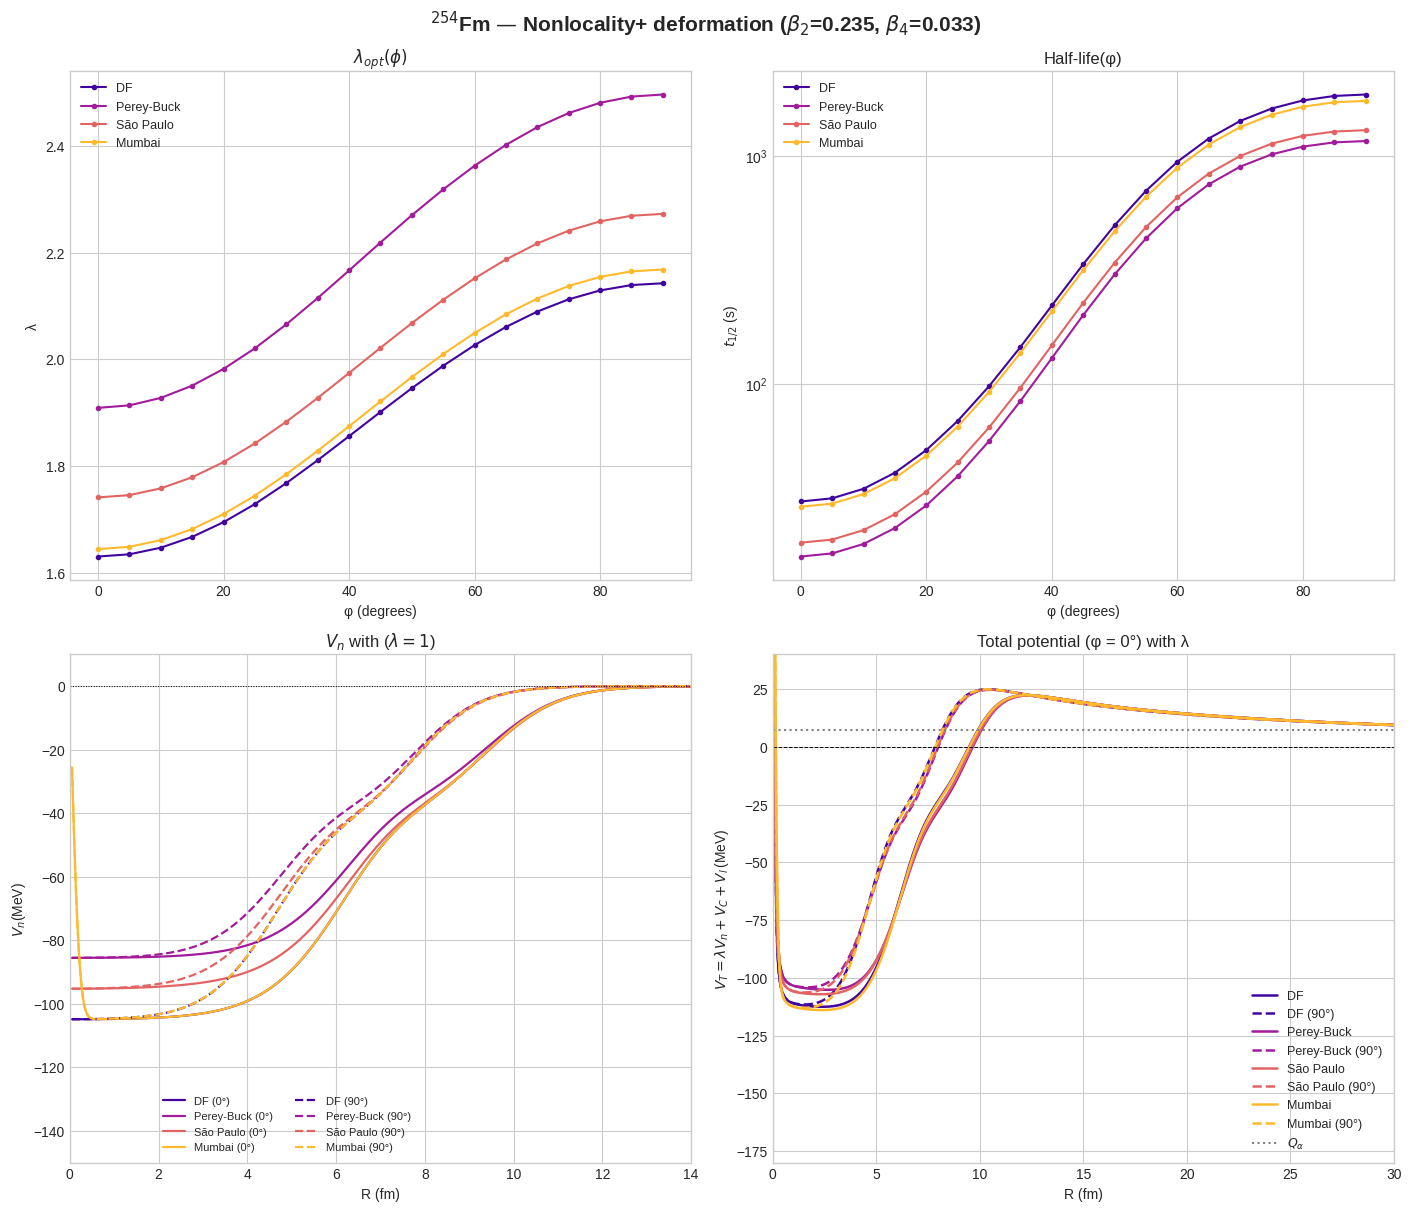

In [3]:
# With beta 2 and beta 4 are positive
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa
═══════════════════════════════════════════════════════════════════════════════

 Alfa   : esférica (densidad gaussiana)
 Hija   : Fermi deformada  ->  R(theta), a(theta)  con Y20, Y40
 Salida : lambda(phi), puntos de retorno, P, N, tau(phi) para los 4 modelos
          + vida media promediada angularmente

 NOTAS FÍSICAS IMPORTANTES (no es "solo sintaxis"):
 ------------------------------------------------------------------
 (1) Perey-Buck y São Paulo son transformaciones NO LINEALES en V.
     => se aplican al potencial nuclear TOTAL a phi fijo,
        NUNCA multipolo por multipolo.
 (2) Mumbai es LINEAL en V  => Mumbai(lam*V) = lam*Mumbai(V).
     Por eso para Mumbai da exactamente igual renormalizar antes o después.
 (3) São Paulo usa V_Coulomb en la exponencial: aquí se usa el
     V_Coulomb(R, phi) de la MISMA orientación.

 CAMBIOS NUMÉRICOS respecto a tus dos códigos:
 ------------------------------------------------------------------
 * j_L: se usa scipy.special.spherical_jn. Tus j2_f/j4_f tenían
   términos 105/x^5 que se rompen para k*r ~ 1e-5 (cancelación
   catastrófica). Ese era un bug latente en el código deformado.
 * theta: cuadratura Gauss-Legendre en u = cos(theta) (64 nodos)
   en vez de Simpson en theta. Más exacta y más barata.
 * Perey-Buck / São Paulo: se resuelven con la función W de Lambert
   (solución EXACTA y vectorizada) en vez de brentq punto por punto.
   Es la misma raíz física que daba tu brentq (rama principal, la que
   tiende a U -> U_bare cuando beta_nl -> 0).
 * Mumbai: se explota que la grilla R es uniforme  => el kernel es
   Toeplitz/Hankel y V((Ri+Rj)/2) vive en una semi-grilla.
   Se reduce de O(N^2) evaluaciones de spline a O(N) + gathers.
 * lambda: barrido grueso + brentq (en vez de 3000 puntos de barrido).
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════
NUCLEUS = dict(name="Fm-254", Z_d=98, A_d=250, Q=7.307, G=22, beta2=0.235, beta4=0.033)

# "after"  -> lambda multiplica el potencial YA transformado  (= tu código 1)
# "before" -> lambda renormaliza el folding desnudo y LUEGO se hace no-local
LAMBDA_MODE = "after"

MAKE_PLOTS = True

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0   # dR ~ 0.025 fm  (necesario para Mumbai)
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0           # densidad de la hija
N_U               = 64                  # nodos Gauss-Legendre en cos(theta)
N_PHI             = 19                  # orientaciones en [0, pi/2] (impar!)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
Z_alpha, A_alpha = 2, 4
e2       = 1.44
a_0      = 0.54
alpha_g  = 0.7024                # ancho gaussiano de la alfa
x_g      = 7999 / 4              # interacción NN (M3Y-like, forma Yukawa doble)
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22       # MeV*s
m_n      = 931.494
L        = 0                     # momento angular del alfa
beta_nl  = 0.2159                  # RANGO DE NO-LOCALIDAD (Perey-Buck / Mumbai)

name  = NUCLEUS["name"]
Z_d   = NUCLEUS["Z_d"]
A_d   = NUCLEUS["A_d"]
Q     = NUCLEUS["Q"]
G     = NUCLEUS["G"]
beta2 = NUCLEUS["beta2"]
beta4 = NUCLEUS["beta4"]

R_0  = 1.07 * A_d ** (1 / 3)
mu   = (A_d * A_alpha) / (A_d + A_alpha) * m_n
B_qn = (G - L + 1) * (np.pi / 2)          # regla de Bohr-Sommerfeld
zpb  = (mu * beta_nl ** 2) / (2 * hbarc ** 2)
r3_C = (Z_alpha * Z_d * e2) / Q           # radio de Coulomb puro (referencia)


# ═════════════════════════════════════════════════════════════════════════════
#  GEOMETRÍA DEFORMADA DE LA HIJA
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def R_f_theta(th):
    return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))


def a_f_theta(th):
    a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
    c, s = np.cos(th), np.sin(th)
    gradR = (R_0 / R_f_theta(th)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)   # int_-1^1 du  == int sin(th) dth
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)

if dR > beta_nl / 4:
    print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {beta_nl} fm "
          f"(Mumbai será impreciso). Sube N_R.")


# ═════════════════════════════════════════════════════════════════════════════
#  DENSIDAD DEFORMADA Y SUS TRANSFORMADAS DE FOURIER MULTIPOLARES
# ═════════════════════════════════════════════════════════════════════════════
Rf_u = R_f_theta(theta_gl)
af_u = a_f_theta(theta_gl)

# fermi[r, u]
fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

# Normalización:  int rho dV = 2*pi * int dr r^2 * int du fermi
I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
norm_N  = A_d / I_geo
norm_Cd = Z_d / I_geo


def fourier_rho2_L(Lm, norm, kchunk=64):
    """rho2_L(k) = 2pi * norm * int dr r^2 int du  j_L(kr) Y_L0(th) fermi(r,u)"""
    out = np.empty(N_K)
    W = w_gl * YLM[Lm](theta_gl)                     # (Nu,)
    r2f = (r ** 2)[:, None] * fermi                  # (Nr, Nu)
    for a0 in range(0, N_K, kchunk):
        kk = k[a0:a0 + kchunk]                       # (nk,)
        jl = spherical_jn(Lm, r[:, None] * kk[None, :])          # (Nr, nk)
        tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)   # (Nu, nk)
        out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
    return out


print(f"\n>>> {name}   (Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
      f"beta2={beta2}, beta4={beta4}, beta_nl={beta_nl} fm)")
t0 = time.time()
print("  [FT] densidad deformada de la hija (L = 0, 2, 4)...")
rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

# --- alfa (esférica, analítica) ----------------------------------------------
I_r1        = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k     = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn     = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc     = (Z_alpha / (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k


# ═════════════════════════════════════════════════════════════════════════════
#  POTENCIALES MULTIPOLARES  ->  V(R, phi)
# ═════════════════════════════════════════════════════════════════════════════
g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


print("  [V]  potenciales multipolares nuclear y Coulomb...")
pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}

V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


PL = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])          # (3, Nphi)

V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
             + V_NN_L[2][:, None] * PL[1][None, :]
             + V_NN_L[4][:, None] * PL[2][None, :])            # (NR, Nphi)

V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
             + V_C_L[2][:, None] * PL[1][None, :]
             + V_C_L[4][:, None] * PL[2][None, :])

V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)   # (NR,)


# ═════════════════════════════════════════════════════════════════════════════
#  NO-LOCALIDAD
# ═════════════════════════════════════════════════════════════════════════════
def _lambert_local(V_bare, E_eff):
    """
    Resuelve   U * exp(zpb * (E_eff - U)) = V_bare   en la rama física.
        t = -zpb*U  ->  t e^t = -zpb * V_bare * exp(-zpb*E_eff)
        U = -W0(arg)/zpb
    Reproduce exactamente la raíz que buscaba tu brentq(-350, 100).
    """
    arg = -zpb * V_bare * np.exp(-zpb * E_eff)
    w = lambertw(arg, k=0)
    U = -np.real(w) / zpb
    bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
    return np.where(bad, V_bare, U)          # fallback: potencial desnudo


def perey_buck(V_bare):
    """U * exp(zpb*(Q - U)) = V_bare"""
    return _lambert_local(V_bare, Q)


def sao_paulo(V_bare, V_C_col):
    """U * exp(zpb*(Q - V_C - U)) = V_bare"""
    return _lambert_local(V_bare, Q - V_C_col)


# --- Mumbai: kernel gaussiano no local, explotando grilla uniforme ------------
_i = np.arange(N_R)
_H = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)                 # semi-grilla
_K1 = np.exp(-((np.arange(-(N_R - 1), N_R) * dR) ** 2) / beta_nl ** 2)   # dep. de i-j
_K2 = np.exp(-((2 * R_MIN + np.arange(2 * N_R - 1) * dR) ** 2) / beta_nl ** 2)  # i+j


def mumbai(V_col, chunk=256):
    """
    V_M(R) = 1/(sqrt(pi) beta) * int dR' V((R+R')/2) *
             [ exp(-(R-R')^2/beta^2) - exp(-(R+R')^2/beta^2) ]
    """
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh = spl(_H)                                    # V en la semi-grilla
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii = _i[i0:i0 + chunk][:, None]
        s = ii + _i[None, :]                        # i+j
        d = ii - _i[None, :] + (N_R - 1)            # i-j desplazado
        ker = _K1[d] - _K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * beta_nl)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTRUCTOR DE POTENCIAL POR MODELO
# ═════════════════════════════════════════════════════════════════════════════
def make_builder(model, VNN_col, VC_col):
    """Devuelve  lam -> V_nuclear_local(R)  para la orientación dada."""
    if model == "DF":
        return lambda lam: lam * VNN_col

    if model == "Mumbai":                      # lineal: antes == después
        VM = mumbai(VNN_col)
        return lambda lam: lam * VM

    if model == "Perey-Buck":
        if LAMBDA_MODE == "after":
            U = perey_buck(VNN_col)
            return lambda lam: lam * U
        return lambda lam: perey_buck(lam * VNN_col)

    if model == "São Paulo":
        if LAMBDA_MODE == "after":
            U = sao_paulo(VNN_col, VC_col)
            return lambda lam: lam * U
        return lambda lam: sao_paulo(lam * VNN_col, VC_col)

    raise ValueError(model)


# ═════════════════════════════════════════════════════════════════════════════
#  BOHR-SOMMERFELD + WKB  PARA UNA ORIENTACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def _spline_and_roots(builder, lam, VC_col):
    V = builder(lam) + VC_col + V_cent
    s = InterpolatedUnivariateSpline(R, Q - V, k=3)
    rts = s.roots()
    if len(rts) < 3:
        return None
    return s, rts[0], rts[1], rts[2]


def action_inner(builder, lam, VC_col):
    out = _spline_and_roots(builder, lam, VC_col)
    if out is None:
        return None
    s, r1, r2, _ = out
    I = quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
             r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]
    return I


def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
    """Busca lambda tal que S_interior(lambda) = B, y devuelve todo lo demás."""
    grid = np.linspace(lam_lo, lam_hi, n_scan)
    f = []
    for lam in grid:
        I = action_inner(builder, lam, VC_col)
        f.append(np.nan if I is None else I - B_qn)
    f = np.array(f)

    lam_opt = None
    ok = np.isfinite(f)
    for a, b in zip(range(n_scan - 1), range(1, n_scan)):
        if ok[a] and ok[b] and f[a] * f[b] < 0:
            lam_opt = brentq(
                lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                grid[a], grid[b], xtol=1e-5)
            break
    if lam_opt is None:                       # no hubo cambio de signo
        if not ok.any():
            return None
        lam_opt = grid[np.nanargmin(np.abs(f))]

    out = _spline_and_roots(builder, lam_opt, VC_col)
    if out is None:
        return None
    s, r1, r2, r3 = out

    # V(r) - Q  =  -s(r)
    I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
               r2, r3, limit=200, points=[r2, r3], epsabs=1e-4, epsrel=1e-4)[0]
    I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
               r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]

    N_norm = 1.0 / I_f
    P = np.exp(-2 * I_G)
    Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
    tau = (hbar * np.log(2)) / Gamma
    return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                P=P, N=N_norm, Gamma=Gamma, tau=tau)


# ═════════════════════════════════════════════════════════════════════════════
#  LOOP PRINCIPAL:  4 modelos  x  N_PHI orientaciones
# ═════════════════════════════════════════════════════════════════════════════
MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]
resultados = {m: [] for m in MODELOS}

for m in MODELOS:
    print(f"  [WKB] {m} ...", end="", flush=True)
    for j in range(N_PHI):
        builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
        resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
    print(" ok")

print(f"  (tiempo total: {time.time() - t0:.1f} s)")


# ═════════════════════════════════════════════════════════════════════════════
#  PROMEDIO ANGULAR
#  El alfa se emite en todas las orientaciones -> se promedia el ANCHO:
#      <Gamma> = int_0^{pi/2} Gamma(phi) sin(phi) dphi / int_0^{pi/2} sin(phi) dphi
#      T_1/2   = hbar ln2 / <Gamma>
# ═════════════════════════════════════════════════════════════════════════════
w_phi = np.sin(phi)
den = simpson(w_phi, x=phi)


def promedio(res_list):
    g = np.array([np.nan if r is None else r["Gamma"] for r in res_list])
    good = np.isfinite(g)
    if not good.any():
        return None
    g = np.where(good, g, 0.0)
    G_avg = simpson(g * w_phi, x=phi) / den
    return G_avg, (hbar * np.log(2)) / G_avg


# ═════════════════════════════════════════════════════════════════════════════
#  TABLAS
# ═════════════════════════════════════════════════════════════════════════════
sep = "=" * 118
print("\n" + sep)
print(f"{name}   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: '{LAMBDA_MODE}')")
print(sep)
print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
      f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
print("-" * 118)
for m in MODELOS:
    for j, res in enumerate(resultados[m]):
        if res is None:
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {'--- sin solución ---':>60}")
            continue
        print(f"{m:<12} {np.degrees(phi[j]):6.1f} {res['lam']:8.4f} "
              f"{res['r1']:8.3f} {res['r2']:8.3f} {res['r3']:8.3f} "
              f"{res['P']:12.3e} {res['N']:10.4f} {res['tau']:13.3e}")
    print("-" * 118)

print("\n" + sep)
print(f"{name}   —  RESUMEN PROMEDIADO ANGULARMENTE       "
      f"(r3 Coulomb puro = {r3_C:.2f} fm)")
print(sep)
print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
      f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
print("-" * 118)
for m in MODELOS:
    lams = np.array([r["lam"] for r in resultados[m] if r is not None])
    t0d = resultados[m][0]
    t90 = resultados[m][-1]
    pr = promedio(resultados[m])
    print(f"{m:<12} {lams.mean():10.4f} "
          f"{(t0d['tau'] if t0d else np.nan):13.3e} "
          f"{(t90['tau'] if t90 else np.nan):13.3e} "
          f"{(pr[0] if pr else np.nan):15.3e} "
          f"{(pr[1] if pr else np.nan):18.3e}")
print(sep + "\n")


# ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    fig.suptitle(rf"$^{{{A_d + 4}}}${name.split('-')[0]} — Nonlocality"
                 rf"+ deformation ($\beta_2$={beta2}, $\beta_4$={beta4})",
                 fontsize=15, fontweight='bold')

    for m in MODELOS:
        ph = np.degrees([phi[j] for j, r in enumerate(resultados[m]) if r])
        lm = [r["lam"] for r in resultados[m] if r]
        tt = [r["tau"] for r in resultados[m] if r]
        ax[0, 0].plot(ph, lm, '-o', ms=3, label=m, color=colors[m])
        ax[0, 1].semilogy(ph, tt, '-o', ms=3, label=m, color=colors[m])

    ax[0, 0].set(xlabel="φ (degrees)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
    ax[0, 1].set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)",
                 title="Half-life(φ)")
    for a in (ax[0, 0], ax[0, 1]):
        a.legend(frameon=False, fontsize=9)

    # potenciales nucleares locales-equivalentes en phi = 0 y 90
    for jj, ls, lbl in ((0, '-', '0°'), (N_PHI - 1, '--', '90°')):
        for m in MODELOS:
            bld = make_builder(m, V_Nuclear[:, jj], V_Coulomb[:, jj])
            ax[1, 0].plot(R, bld(1.0), ls, lw=1.6, color=colors[m],
                          label=f"{m} ({lbl})")
    ax[1, 0].set(xlabel="R (fm)", ylabel=r"$V_{n}$(MeV)", xlim=(0, 14), ylim=(-150, 10),
                 title=r"$V_{n}$ with ($\lambda=1$)")
    ax[1, 0].axhline(0, color='k', lw=0.7, ls=':')
    ax[1, 0].legend(fontsize=8, ncol=2, loc='lower center', bbox_to_anchor=(0.35, 0))

    # potencial total
    j0, j90 = 0, N_PHI - 1
    for m in MODELOS:
        res = resultados[m][0]
        if res is None:
            continue
        bld = make_builder(m, V_Nuclear[:, j0], V_Coulomb[:, j0])
        ax[1, 1].plot(R, bld(res["lam"]) + V_Coulomb[:, j0] + V_cent,
                      lw=1.8, color=colors[m], label=m)
        bld90 = make_builder(m, V_Nuclear[:, j90], V_Coulomb[:, j90])
        ax[1, 1].plot(R, bld90(res["lam"]) + V_Coulomb[:, j90] + V_cent,
                  lw=1.8, ls='--', color=colors[m], label=f"{m} (90°)")

    ax[1, 1].axhline(Q, color='gray', ls=':', lw=1.5, label=r"$Q_\alpha$")
    ax[1, 1].axhline(0, color='k', lw=0.7, ls='--')
    ax[1, 1].set(xlabel="R (fm)", ylabel=r"$V_{T}=λV_{n}+V_{C}+V_{l}\,$(MeV)", xlim=(0, 30), ylim=(-180, 40),
                 title="Total potential (φ = 0°) with λ")
    ax[1, 1].legend(fontsize=9, frameon=False)
    plt.savefig('Fm-254-nonlocal-deformation.png')
    plt.show()


>>> U-216   (Z_hija=90, A_hija=212, Q=8.53 MeV, beta2=-0.07, beta4=-0.013, beta_nl=0.2165 fm)
  [FT] densidad deformada de la hija (L = 0, 2, 4)...
  [V]  potenciales multipolares nuclear y Coulomb...
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (tiempo total: 37.8 s)

U-216   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: 'after')
Modelo          phi   lambda       r1       r2       r3            P          N      t1/2 (s)
----------------------------------------------------------------------------------------------------------------------
DF              0.0   2.2027    0.084    8.440   30.293    1.197e-18     0.3776     1.897e-04
DF              5.0   2.2008    0.084    8.445   30.294    1.220e-18     0.3771     1.863e-04
DF             10.0   2.1952    0.085    8.460   30.295    1.291e-18     0.3755     1.767e-04
DF             15.0   2.1862    0.085    8.484   30.297    1.411e-18     0.3731     1.628e-04
DF             20.0   2.17

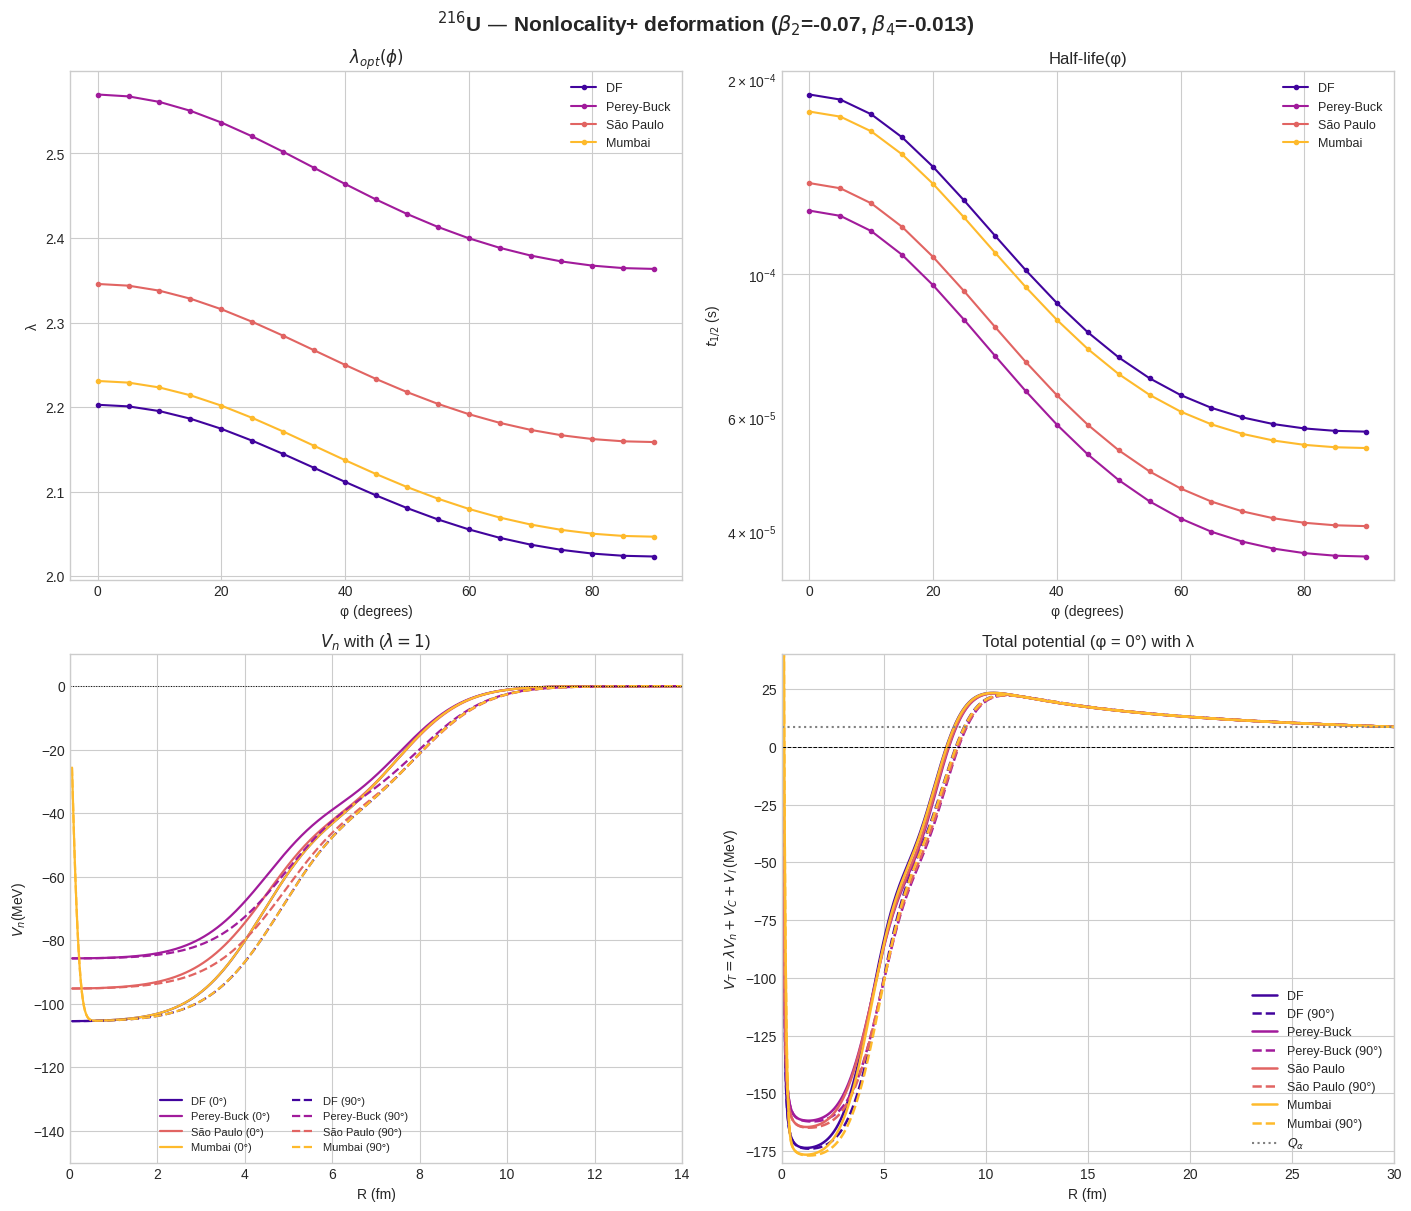

In [2]:
# With beta 2 and beta 4 are positive
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa
═══════════════════════════════════════════════════════════════════════════════

 Alfa   : esférica (densidad gaussiana)
 Hija   : Fermi deformada  ->  R(theta), a(theta)  con Y20, Y40
 Salida : lambda(phi), puntos de retorno, P, N, tau(phi) para los 4 modelos
          + vida media promediada angularmente

 NOTAS FÍSICAS IMPORTANTES (no es "solo sintaxis"):
 ------------------------------------------------------------------
 (1) Perey-Buck y São Paulo son transformaciones NO LINEALES en V.
     => se aplican al potencial nuclear TOTAL a phi fijo,
        NUNCA multipolo por multipolo.
 (2) Mumbai es LINEAL en V  => Mumbai(lam*V) = lam*Mumbai(V).
     Por eso para Mumbai da exactamente igual renormalizar antes o después.
 (3) São Paulo usa V_Coulomb en la exponencial: aquí se usa el
     V_Coulomb(R, phi) de la MISMA orientación.

 CAMBIOS NUMÉRICOS respecto a tus dos códigos:
 ------------------------------------------------------------------
 * j_L: se usa scipy.special.spherical_jn. Tus j2_f/j4_f tenían
   términos 105/x^5 que se rompen para k*r ~ 1e-5 (cancelación
   catastrófica). Ese era un bug latente en el código deformado.
 * theta: cuadratura Gauss-Legendre en u = cos(theta) (64 nodos)
   en vez de Simpson en theta. Más exacta y más barata.
 * Perey-Buck / São Paulo: se resuelven con la función W de Lambert
   (solución EXACTA y vectorizada) en vez de brentq punto por punto.
   Es la misma raíz física que daba tu brentq (rama principal, la que
   tiende a U -> U_bare cuando beta_nl -> 0).
 * Mumbai: se explota que la grilla R es uniforme  => el kernel es
   Toeplitz/Hankel y V((Ri+Rj)/2) vive en una semi-grilla.
   Se reduce de O(N^2) evaluaciones de spline a O(N) + gathers.
 * lambda: barrido grueso + brentq (en vez de 3000 puntos de barrido).
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════
NUCLEUS = dict(name="U-216", Z_d=90, A_d=212, Q=8.53, G=22, beta2=-0.07, beta4=-0.013)

# "after"  -> lambda multiplica el potencial YA transformado  (= tu código 1)
# "before" -> lambda renormaliza el folding desnudo y LUEGO se hace no-local
LAMBDA_MODE = "after"

MAKE_PLOTS = True

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0   # dR ~ 0.025 fm  (necesario para Mumbai)
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0           # densidad de la hija
N_U               = 64                  # nodos Gauss-Legendre en cos(theta)
N_PHI             = 19                  # orientaciones en [0, pi/2] (impar!)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
Z_alpha, A_alpha = 2, 4
e2       = 1.44
a_0      = 0.54
alpha_g  = 0.7024                # ancho gaussiano de la alfa
x_g      = 7999 / 4              # interacción NN (M3Y-like, forma Yukawa doble)
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22       # MeV*s
m_n      = 931.494
L        = 0                     # momento angular del alfa
beta_nl  = 0.2165                  # RANGO DE NO-LOCALIDAD (Perey-Buck / Mumbai)

name  = NUCLEUS["name"]
Z_d   = NUCLEUS["Z_d"]
A_d   = NUCLEUS["A_d"]
Q     = NUCLEUS["Q"]
G     = NUCLEUS["G"]
beta2 = NUCLEUS["beta2"]
beta4 = NUCLEUS["beta4"]

R_0  = 1.07 * A_d ** (1 / 3)
mu   = (A_d * A_alpha) / (A_d + A_alpha) * m_n
B_qn = (G - L + 1) * (np.pi / 2)          # regla de Bohr-Sommerfeld
zpb  = (mu * beta_nl ** 2) / (2 * hbarc ** 2)
r3_C = (Z_alpha * Z_d * e2) / Q           # radio de Coulomb puro (referencia)


# ═════════════════════════════════════════════════════════════════════════════
#  GEOMETRÍA DEFORMADA DE LA HIJA
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def R_f_theta(th):
    return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))


def a_f_theta(th):
    a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
    c, s = np.cos(th), np.sin(th)
    gradR = (R_0 / R_f_theta(th)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)   # int_-1^1 du  == int sin(th) dth
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)

if dR > beta_nl / 4:
    print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {beta_nl} fm "
          f"(Mumbai será impreciso). Sube N_R.")


# ═════════════════════════════════════════════════════════════════════════════
#  DENSIDAD DEFORMADA Y SUS TRANSFORMADAS DE FOURIER MULTIPOLARES
# ═════════════════════════════════════════════════════════════════════════════
Rf_u = R_f_theta(theta_gl)
af_u = a_f_theta(theta_gl)

# fermi[r, u]
fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

# Normalización:  int rho dV = 2*pi * int dr r^2 * int du fermi
I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
norm_N  = A_d / I_geo
norm_Cd = Z_d / I_geo


def fourier_rho2_L(Lm, norm, kchunk=64):
    """rho2_L(k) = 2pi * norm * int dr r^2 int du  j_L(kr) Y_L0(th) fermi(r,u)"""
    out = np.empty(N_K)
    W = w_gl * YLM[Lm](theta_gl)                     # (Nu,)
    r2f = (r ** 2)[:, None] * fermi                  # (Nr, Nu)
    for a0 in range(0, N_K, kchunk):
        kk = k[a0:a0 + kchunk]                       # (nk,)
        jl = spherical_jn(Lm, r[:, None] * kk[None, :])          # (Nr, nk)
        tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)   # (Nu, nk)
        out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
    return out


print(f"\n>>> {name}   (Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
      f"beta2={beta2}, beta4={beta4}, beta_nl={beta_nl} fm)")
t0 = time.time()
print("  [FT] densidad deformada de la hija (L = 0, 2, 4)...")
rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

# --- alfa (esférica, analítica) ----------------------------------------------
I_r1        = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k     = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn     = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc     = (Z_alpha / (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k


# ═════════════════════════════════════════════════════════════════════════════
#  POTENCIALES MULTIPOLARES  ->  V(R, phi)
# ═════════════════════════════════════════════════════════════════════════════
g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


print("  [V]  potenciales multipolares nuclear y Coulomb...")
pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}

V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


PL = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])          # (3, Nphi)

V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
             + V_NN_L[2][:, None] * PL[1][None, :]
             + V_NN_L[4][:, None] * PL[2][None, :])            # (NR, Nphi)

V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
             + V_C_L[2][:, None] * PL[1][None, :]
             + V_C_L[4][:, None] * PL[2][None, :])

V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)   # (NR,)


# ═════════════════════════════════════════════════════════════════════════════
#  NO-LOCALIDAD
# ═════════════════════════════════════════════════════════════════════════════
def _lambert_local(V_bare, E_eff):
    """
    Resuelve   U * exp(zpb * (E_eff - U)) = V_bare   en la rama física.
        t = -zpb*U  ->  t e^t = -zpb * V_bare * exp(-zpb*E_eff)
        U = -W0(arg)/zpb
    Reproduce exactamente la raíz que buscaba tu brentq(-350, 100).
    """
    arg = -zpb * V_bare * np.exp(-zpb * E_eff)
    w = lambertw(arg, k=0)
    U = -np.real(w) / zpb
    bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
    return np.where(bad, V_bare, U)          # fallback: potencial desnudo


def perey_buck(V_bare):
    """U * exp(zpb*(Q - U)) = V_bare"""
    return _lambert_local(V_bare, Q)


def sao_paulo(V_bare, V_C_col):
    """U * exp(zpb*(Q - V_C - U)) = V_bare"""
    return _lambert_local(V_bare, Q - V_C_col)


# --- Mumbai: kernel gaussiano no local, explotando grilla uniforme ------------
_i = np.arange(N_R)
_H = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)                 # semi-grilla
_K1 = np.exp(-((np.arange(-(N_R - 1), N_R) * dR) ** 2) / beta_nl ** 2)   # dep. de i-j
_K2 = np.exp(-((2 * R_MIN + np.arange(2 * N_R - 1) * dR) ** 2) / beta_nl ** 2)  # i+j


def mumbai(V_col, chunk=256):
    """
    V_M(R) = 1/(sqrt(pi) beta) * int dR' V((R+R')/2) *
             [ exp(-(R-R')^2/beta^2) - exp(-(R+R')^2/beta^2) ]
    """
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh = spl(_H)                                    # V en la semi-grilla
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii = _i[i0:i0 + chunk][:, None]
        s = ii + _i[None, :]                        # i+j
        d = ii - _i[None, :] + (N_R - 1)            # i-j desplazado
        ker = _K1[d] - _K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * beta_nl)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTRUCTOR DE POTENCIAL POR MODELO
# ═════════════════════════════════════════════════════════════════════════════
def make_builder(model, VNN_col, VC_col):
    """Devuelve  lam -> V_nuclear_local(R)  para la orientación dada."""
    if model == "DF":
        return lambda lam: lam * VNN_col

    if model == "Mumbai":                      # lineal: antes == después
        VM = mumbai(VNN_col)
        return lambda lam: lam * VM

    if model == "Perey-Buck":
        if LAMBDA_MODE == "after":
            U = perey_buck(VNN_col)
            return lambda lam: lam * U
        return lambda lam: perey_buck(lam * VNN_col)

    if model == "São Paulo":
        if LAMBDA_MODE == "after":
            U = sao_paulo(VNN_col, VC_col)
            return lambda lam: lam * U
        return lambda lam: sao_paulo(lam * VNN_col, VC_col)

    raise ValueError(model)


# ═════════════════════════════════════════════════════════════════════════════
#  BOHR-SOMMERFELD + WKB  PARA UNA ORIENTACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def _spline_and_roots(builder, lam, VC_col):
    V = builder(lam) + VC_col + V_cent
    s = InterpolatedUnivariateSpline(R, Q - V, k=3)
    rts = s.roots()
    if len(rts) < 3:
        return None
    return s, rts[0], rts[1], rts[2]


def action_inner(builder, lam, VC_col):
    out = _spline_and_roots(builder, lam, VC_col)
    if out is None:
        return None
    s, r1, r2, _ = out
    I = quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
             r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]
    return I


def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
    """Busca lambda tal que S_interior(lambda) = B, y devuelve todo lo demás."""
    grid = np.linspace(lam_lo, lam_hi, n_scan)
    f = []
    for lam in grid:
        I = action_inner(builder, lam, VC_col)
        f.append(np.nan if I is None else I - B_qn)
    f = np.array(f)

    lam_opt = None
    ok = np.isfinite(f)
    for a, b in zip(range(n_scan - 1), range(1, n_scan)):
        if ok[a] and ok[b] and f[a] * f[b] < 0:
            lam_opt = brentq(
                lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                grid[a], grid[b], xtol=1e-5)
            break
    if lam_opt is None:                       # no hubo cambio de signo
        if not ok.any():
            return None
        lam_opt = grid[np.nanargmin(np.abs(f))]

    out = _spline_and_roots(builder, lam_opt, VC_col)
    if out is None:
        return None
    s, r1, r2, r3 = out

    # V(r) - Q  =  -s(r)
    I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
               r2, r3, limit=200, points=[r2, r3], epsabs=1e-4, epsrel=1e-4)[0]
    I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
               r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]

    N_norm = 1.0 / I_f
    P = np.exp(-2 * I_G)
    Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
    tau = (hbar * np.log(2)) / Gamma
    return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                P=P, N=N_norm, Gamma=Gamma, tau=tau)


# ═════════════════════════════════════════════════════════════════════════════
#  LOOP PRINCIPAL:  4 modelos  x  N_PHI orientaciones
# ═════════════════════════════════════════════════════════════════════════════
MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]
resultados = {m: [] for m in MODELOS}

for m in MODELOS:
    print(f"  [WKB] {m} ...", end="", flush=True)
    for j in range(N_PHI):
        builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
        resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
    print(" ok")

print(f"  (tiempo total: {time.time() - t0:.1f} s)")


# ═════════════════════════════════════════════════════════════════════════════
#  PROMEDIO ANGULAR
#  El alfa se emite en todas las orientaciones -> se promedia el ANCHO:
#      <Gamma> = int_0^{pi/2} Gamma(phi) sin(phi) dphi / int_0^{pi/2} sin(phi) dphi
#      T_1/2   = hbar ln2 / <Gamma>
# ═════════════════════════════════════════════════════════════════════════════
w_phi = np.sin(phi)
den = simpson(w_phi, x=phi)


def promedio(res_list):
    g = np.array([np.nan if r is None else r["Gamma"] for r in res_list])
    good = np.isfinite(g)
    if not good.any():
        return None
    g = np.where(good, g, 0.0)
    G_avg = simpson(g * w_phi, x=phi) / den
    return G_avg, (hbar * np.log(2)) / G_avg


# ═════════════════════════════════════════════════════════════════════════════
#  TABLAS
# ═════════════════════════════════════════════════════════════════════════════
sep = "=" * 118
print("\n" + sep)
print(f"{name}   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: '{LAMBDA_MODE}')")
print(sep)
print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
      f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
print("-" * 118)
for m in MODELOS:
    for j, res in enumerate(resultados[m]):
        if res is None:
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {'--- sin solución ---':>60}")
            continue
        print(f"{m:<12} {np.degrees(phi[j]):6.1f} {res['lam']:8.4f} "
              f"{res['r1']:8.3f} {res['r2']:8.3f} {res['r3']:8.3f} "
              f"{res['P']:12.3e} {res['N']:10.4f} {res['tau']:13.3e}")
    print("-" * 118)

print("\n" + sep)
print(f"{name}   —  RESUMEN PROMEDIADO ANGULARMENTE       "
      f"(r3 Coulomb puro = {r3_C:.2f} fm)")
print(sep)
print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
      f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
print("-" * 118)
for m in MODELOS:
    lams = np.array([r["lam"] for r in resultados[m] if r is not None])
    t0d = resultados[m][0]
    t90 = resultados[m][-1]
    pr = promedio(resultados[m])
    print(f"{m:<12} {lams.mean():10.4f} "
          f"{(t0d['tau'] if t0d else np.nan):13.3e} "
          f"{(t90['tau'] if t90 else np.nan):13.3e} "
          f"{(pr[0] if pr else np.nan):15.3e} "
          f"{(pr[1] if pr else np.nan):18.3e}")
print(sep + "\n")


# ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    fig.suptitle(rf"$^{{{A_d + 4}}}${name.split('-')[0]} — Nonlocality"
                 rf"+ deformation ($\beta_2$={beta2}, $\beta_4$={beta4})",
                 fontsize=15, fontweight='bold')

    for m in MODELOS:
        ph = np.degrees([phi[j] for j, r in enumerate(resultados[m]) if r])
        lm = [r["lam"] for r in resultados[m] if r]
        tt = [r["tau"] for r in resultados[m] if r]
        ax[0, 0].plot(ph, lm, '-o', ms=3, label=m, color=colors[m])
        ax[0, 1].semilogy(ph, tt, '-o', ms=3, label=m, color=colors[m])

    ax[0, 0].set(xlabel="φ (degrees)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
    ax[0, 1].set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)",
                 title="Half-life(φ)")
    for a in (ax[0, 0], ax[0, 1]):
        a.legend(frameon=False, fontsize=9)

    # potenciales nucleares locales-equivalentes en phi = 0 y 90
    for jj, ls, lbl in ((0, '-', '0°'), (N_PHI - 1, '--', '90°')):
        for m in MODELOS:
            bld = make_builder(m, V_Nuclear[:, jj], V_Coulomb[:, jj])
            ax[1, 0].plot(R, bld(1.0), ls, lw=1.6, color=colors[m],
                          label=f"{m} ({lbl})")
    ax[1, 0].set(xlabel="R (fm)", ylabel=r"$V_{n}$(MeV)", xlim=(0, 14), ylim=(-150, 10),
                 title=r"$V_{n}$ with ($\lambda=1$)")
    ax[1, 0].axhline(0, color='k', lw=0.7, ls=':')
    ax[1, 0].legend(fontsize=8, ncol=2, loc='lower center', bbox_to_anchor=(0.35, 0))

    # potencial total
    j0, j90 = 0, N_PHI - 1
    for m in MODELOS:
        res = resultados[m][0]
        if res is None:
            continue
        bld = make_builder(m, V_Nuclear[:, j0], V_Coulomb[:, j0])
        ax[1, 1].plot(R, bld(res["lam"]) + V_Coulomb[:, j0] + V_cent,
                      lw=1.8, color=colors[m], label=m)
        bld90 = make_builder(m, V_Nuclear[:, j90], V_Coulomb[:, j90])
        ax[1, 1].plot(R, bld90(res["lam"]) + V_Coulomb[:, j90] + V_cent,
                  lw=1.8, ls='--', color=colors[m], label=f"{m} (90°)")

    ax[1, 1].axhline(Q, color='gray', ls=':', lw=1.5, label=r"$Q_\alpha$")
    ax[1, 1].axhline(0, color='k', lw=0.7, ls='--')
    ax[1, 1].set(xlabel="R (fm)", ylabel=r"$V_{T}=λV_{n}+V_{C}+V_{l}\,$(MeV)", xlim=(0, 30), ylim=(-180, 40),
                 title="Total potential (φ = 0°) with λ")
    ax[1, 1].legend(fontsize=9, frameon=False)
    plt.savefig('U-216-nonlocal-deformation.png')
    plt.show()


>>> U-216   (Z_hija=90, A_hija=217, Q=9.435 MeV, beta2=-0.018, beta4=0.008, beta_nl=0.2168 fm)
  [FT] densidad deformada de la hija (L = 0, 2, 4)...
  [V]  potenciales multipolares nuclear y Coulomb...
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (tiempo total: 33.2 s)

U-216   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: 'after')
Modelo          phi   lambda       r1       r2       r3            P          N      t1/2 (s)
----------------------------------------------------------------------------------------------------------------------
DF              0.0   2.0435    0.799    8.715   27.823    1.584e-16     0.3502     1.546e-06
DF              5.0   2.0435    0.799    8.715   27.823    1.579e-16     0.3503     1.550e-06
DF             10.0   2.0435    0.799    8.713   27.823    1.566e-16     0.3505     1.562e-06
DF             15.0   2.0433    0.799    8.711   27.824    1.546e-16     0.3508     1.581e-06
DF             20.0   2.0

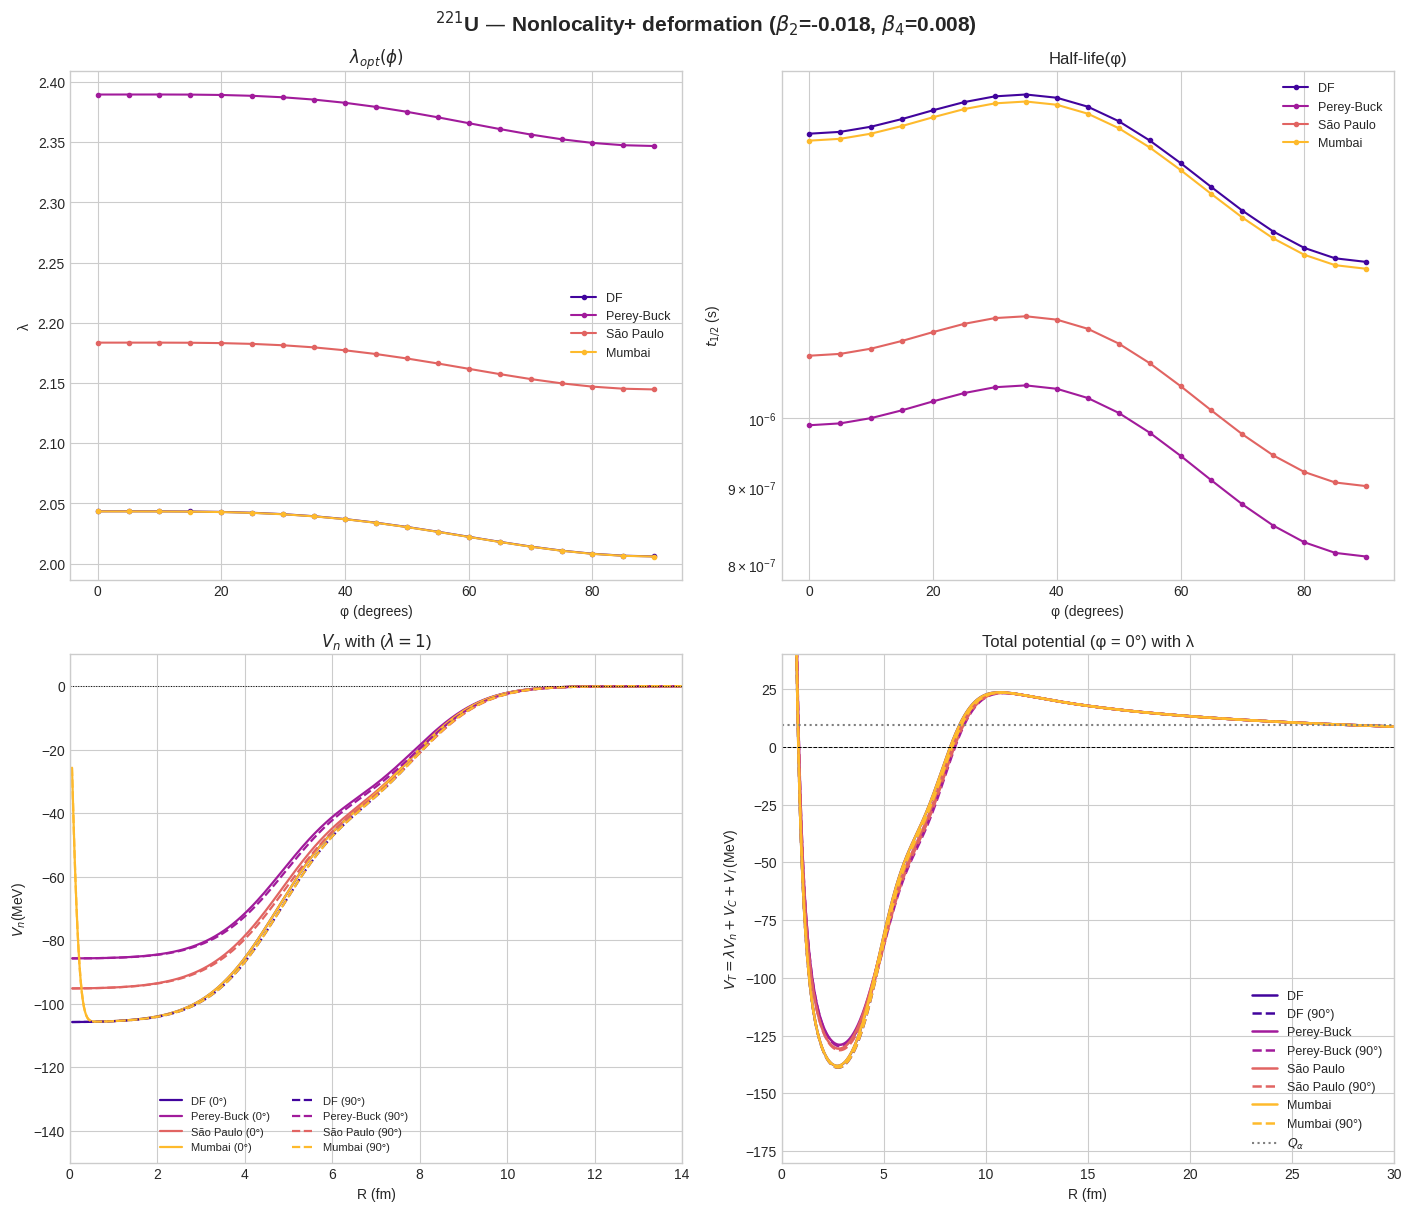

In [1]:
# With beta 2 and beta 4 are positive
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa
═══════════════════════════════════════════════════════════════════════════════

 Alfa   : esférica (densidad gaussiana)
 Hija   : Fermi deformada  ->  R(theta), a(theta)  con Y20, Y40
 Salida : lambda(phi), puntos de retorno, P, N, tau(phi) para los 4 modelos
          + vida media promediada angularmente

 NOTAS FÍSICAS IMPORTANTES (no es "solo sintaxis"):
 ------------------------------------------------------------------
 (1) Perey-Buck y São Paulo son transformaciones NO LINEALES en V.
     => se aplican al potencial nuclear TOTAL a phi fijo,
        NUNCA multipolo por multipolo.
 (2) Mumbai es LINEAL en V  => Mumbai(lam*V) = lam*Mumbai(V).
     Por eso para Mumbai da exactamente igual renormalizar antes o después.
 (3) São Paulo usa V_Coulomb en la exponencial: aquí se usa el
     V_Coulomb(R, phi) de la MISMA orientación.

 CAMBIOS NUMÉRICOS respecto a tus dos códigos:
 ------------------------------------------------------------------
 * j_L: se usa scipy.special.spherical_jn. Tus j2_f/j4_f tenían
   términos 105/x^5 que se rompen para k*r ~ 1e-5 (cancelación
   catastrófica). Ese era un bug latente en el código deformado.
 * theta: cuadratura Gauss-Legendre en u = cos(theta) (64 nodos)
   en vez de Simpson en theta. Más exacta y más barata.
 * Perey-Buck / São Paulo: se resuelven con la función W de Lambert
   (solución EXACTA y vectorizada) en vez de brentq punto por punto.
   Es la misma raíz física que daba tu brentq (rama principal, la que
   tiende a U -> U_bare cuando beta_nl -> 0).
 * Mumbai: se explota que la grilla R es uniforme  => el kernel es
   Toeplitz/Hankel y V((Ri+Rj)/2) vive en una semi-grilla.
   Se reduce de O(N^2) evaluaciones de spline a O(N) + gathers.
 * lambda: barrido grueso + brentq (en vez de 3000 puntos de barrido).
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════
NUCLEUS = dict(name="U-216", Z_d=90, A_d=217, Q=9.435, G=22, beta2=-0.018, beta4=0.008)

# "after"  -> lambda multiplica el potencial YA transformado  (= tu código 1)
# "before" -> lambda renormaliza el folding desnudo y LUEGO se hace no-local
LAMBDA_MODE = "after"

MAKE_PLOTS = True

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0   # dR ~ 0.025 fm  (necesario para Mumbai)
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0           # densidad de la hija
N_U               = 64                  # nodos Gauss-Legendre en cos(theta)
N_PHI             = 19                  # orientaciones en [0, pi/2] (impar!)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
Z_alpha, A_alpha = 2, 4
e2       = 1.44
a_0      = 0.54
alpha_g  = 0.7024                # ancho gaussiano de la alfa
x_g      = 7999 / 4              # interacción NN (M3Y-like, forma Yukawa doble)
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22       # MeV*s
m_n      = 931.494
L        = 4                     # momento angular del alfa
beta_nl  = 0.2168                  # RANGO DE NO-LOCALIDAD (Perey-Buck / Mumbai)

name  = NUCLEUS["name"]
Z_d   = NUCLEUS["Z_d"]
A_d   = NUCLEUS["A_d"]
Q     = NUCLEUS["Q"]
G     = NUCLEUS["G"]
beta2 = NUCLEUS["beta2"]
beta4 = NUCLEUS["beta4"]

R_0  = 1.07 * A_d ** (1 / 3)
mu   = (A_d * A_alpha) / (A_d + A_alpha) * m_n
B_qn = (G - L + 1) * (np.pi / 2)          # regla de Bohr-Sommerfeld
zpb  = (mu * beta_nl ** 2) / (2 * hbarc ** 2)
r3_C = (Z_alpha * Z_d * e2) / Q           # radio de Coulomb puro (referencia)


# ═════════════════════════════════════════════════════════════════════════════
#  GEOMETRÍA DEFORMADA DE LA HIJA
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def R_f_theta(th):
    return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))


def a_f_theta(th):
    a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
    c, s = np.cos(th), np.sin(th)
    gradR = (R_0 / R_f_theta(th)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)   # int_-1^1 du  == int sin(th) dth
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)

if dR > beta_nl / 4:
    print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {beta_nl} fm "
          f"(Mumbai será impreciso). Sube N_R.")


# ═════════════════════════════════════════════════════════════════════════════
#  DENSIDAD DEFORMADA Y SUS TRANSFORMADAS DE FOURIER MULTIPOLARES
# ═════════════════════════════════════════════════════════════════════════════
Rf_u = R_f_theta(theta_gl)
af_u = a_f_theta(theta_gl)

# fermi[r, u]
fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

# Normalización:  int rho dV = 2*pi * int dr r^2 * int du fermi
I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
norm_N  = A_d / I_geo
norm_Cd = Z_d / I_geo


def fourier_rho2_L(Lm, norm, kchunk=64):
    """rho2_L(k) = 2pi * norm * int dr r^2 int du  j_L(kr) Y_L0(th) fermi(r,u)"""
    out = np.empty(N_K)
    W = w_gl * YLM[Lm](theta_gl)                     # (Nu,)
    r2f = (r ** 2)[:, None] * fermi                  # (Nr, Nu)
    for a0 in range(0, N_K, kchunk):
        kk = k[a0:a0 + kchunk]                       # (nk,)
        jl = spherical_jn(Lm, r[:, None] * kk[None, :])          # (Nr, nk)
        tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)   # (Nu, nk)
        out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
    return out


print(f"\n>>> {name}   (Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
      f"beta2={beta2}, beta4={beta4}, beta_nl={beta_nl} fm)")
t0 = time.time()
print("  [FT] densidad deformada de la hija (L = 0, 2, 4)...")
rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

# --- alfa (esférica, analítica) ----------------------------------------------
I_r1        = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k     = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn     = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc     = (Z_alpha / (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k


# ═════════════════════════════════════════════════════════════════════════════
#  POTENCIALES MULTIPOLARES  ->  V(R, phi)
# ═════════════════════════════════════════════════════════════════════════════
g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


print("  [V]  potenciales multipolares nuclear y Coulomb...")
pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}

V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


PL = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])          # (3, Nphi)

V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
             + V_NN_L[2][:, None] * PL[1][None, :]
             + V_NN_L[4][:, None] * PL[2][None, :])            # (NR, Nphi)

V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
             + V_C_L[2][:, None] * PL[1][None, :]
             + V_C_L[4][:, None] * PL[2][None, :])

V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)   # (NR,)


# ═════════════════════════════════════════════════════════════════════════════
#  NO-LOCALIDAD
# ═════════════════════════════════════════════════════════════════════════════
def _lambert_local(V_bare, E_eff):
    """
    Resuelve   U * exp(zpb * (E_eff - U)) = V_bare   en la rama física.
        t = -zpb*U  ->  t e^t = -zpb * V_bare * exp(-zpb*E_eff)
        U = -W0(arg)/zpb
    Reproduce exactamente la raíz que buscaba tu brentq(-350, 100).
    """
    arg = -zpb * V_bare * np.exp(-zpb * E_eff)
    w = lambertw(arg, k=0)
    U = -np.real(w) / zpb
    bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
    return np.where(bad, V_bare, U)          # fallback: potencial desnudo


def perey_buck(V_bare):
    """U * exp(zpb*(Q - U)) = V_bare"""
    return _lambert_local(V_bare, Q)


def sao_paulo(V_bare, V_C_col):
    """U * exp(zpb*(Q - V_C - U)) = V_bare"""
    return _lambert_local(V_bare, Q - V_C_col)


# --- Mumbai: kernel gaussiano no local, explotando grilla uniforme ------------
_i = np.arange(N_R)
_H = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)                 # semi-grilla
_K1 = np.exp(-((np.arange(-(N_R - 1), N_R) * dR) ** 2) / beta_nl ** 2)   # dep. de i-j
_K2 = np.exp(-((2 * R_MIN + np.arange(2 * N_R - 1) * dR) ** 2) / beta_nl ** 2)  # i+j


def mumbai(V_col, chunk=256):
    """
    V_M(R) = 1/(sqrt(pi) beta) * int dR' V((R+R')/2) *
             [ exp(-(R-R')^2/beta^2) - exp(-(R+R')^2/beta^2) ]
    """
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh = spl(_H)                                    # V en la semi-grilla
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii = _i[i0:i0 + chunk][:, None]
        s = ii + _i[None, :]                        # i+j
        d = ii - _i[None, :] + (N_R - 1)            # i-j desplazado
        ker = _K1[d] - _K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * beta_nl)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTRUCTOR DE POTENCIAL POR MODELO
# ═════════════════════════════════════════════════════════════════════════════
def make_builder(model, VNN_col, VC_col):
    """Devuelve  lam -> V_nuclear_local(R)  para la orientación dada."""
    if model == "DF":
        return lambda lam: lam * VNN_col

    if model == "Mumbai":                      # lineal: antes == después
        VM = mumbai(VNN_col)
        return lambda lam: lam * VM

    if model == "Perey-Buck":
        if LAMBDA_MODE == "after":
            U = perey_buck(VNN_col)
            return lambda lam: lam * U
        return lambda lam: perey_buck(lam * VNN_col)

    if model == "São Paulo":
        if LAMBDA_MODE == "after":
            U = sao_paulo(VNN_col, VC_col)
            return lambda lam: lam * U
        return lambda lam: sao_paulo(lam * VNN_col, VC_col)

    raise ValueError(model)


# ═════════════════════════════════════════════════════════════════════════════
#  BOHR-SOMMERFELD + WKB  PARA UNA ORIENTACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def _spline_and_roots(builder, lam, VC_col):
    V = builder(lam) + VC_col + V_cent
    s = InterpolatedUnivariateSpline(R, Q - V, k=3)
    rts = s.roots()
    if len(rts) < 3:
        return None
    return s, rts[0], rts[1], rts[2]


def action_inner(builder, lam, VC_col):
    out = _spline_and_roots(builder, lam, VC_col)
    if out is None:
        return None
    s, r1, r2, _ = out
    I = quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
             r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]
    return I


def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
    """Busca lambda tal que S_interior(lambda) = B, y devuelve todo lo demás."""
    grid = np.linspace(lam_lo, lam_hi, n_scan)
    f = []
    for lam in grid:
        I = action_inner(builder, lam, VC_col)
        f.append(np.nan if I is None else I - B_qn)
    f = np.array(f)

    lam_opt = None
    ok = np.isfinite(f)
    for a, b in zip(range(n_scan - 1), range(1, n_scan)):
        if ok[a] and ok[b] and f[a] * f[b] < 0:
            lam_opt = brentq(
                lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                grid[a], grid[b], xtol=1e-5)
            break
    if lam_opt is None:                       # no hubo cambio de signo
        if not ok.any():
            return None
        lam_opt = grid[np.nanargmin(np.abs(f))]

    out = _spline_and_roots(builder, lam_opt, VC_col)
    if out is None:
        return None
    s, r1, r2, r3 = out

    # V(r) - Q  =  -s(r)
    I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
               r2, r3, limit=200, points=[r2, r3], epsabs=1e-4, epsrel=1e-4)[0]
    I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
               r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]

    N_norm = 1.0 / I_f
    P = np.exp(-2 * I_G)
    Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
    tau = (hbar * np.log(2)) / Gamma
    return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                P=P, N=N_norm, Gamma=Gamma, tau=tau)


# ═════════════════════════════════════════════════════════════════════════════
#  LOOP PRINCIPAL:  4 modelos  x  N_PHI orientaciones
# ═════════════════════════════════════════════════════════════════════════════
MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]
resultados = {m: [] for m in MODELOS}

for m in MODELOS:
    print(f"  [WKB] {m} ...", end="", flush=True)
    for j in range(N_PHI):
        builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
        resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
    print(" ok")

print(f"  (tiempo total: {time.time() - t0:.1f} s)")


# ═════════════════════════════════════════════════════════════════════════════
#  PROMEDIO ANGULAR
#  El alfa se emite en todas las orientaciones -> se promedia el ANCHO:
#      <Gamma> = int_0^{pi/2} Gamma(phi) sin(phi) dphi / int_0^{pi/2} sin(phi) dphi
#      T_1/2   = hbar ln2 / <Gamma>
# ═════════════════════════════════════════════════════════════════════════════
w_phi = np.sin(phi)
den = simpson(w_phi, x=phi)


def promedio(res_list):
    g = np.array([np.nan if r is None else r["Gamma"] for r in res_list])
    good = np.isfinite(g)
    if not good.any():
        return None
    g = np.where(good, g, 0.0)
    G_avg = simpson(g * w_phi, x=phi) / den
    return G_avg, (hbar * np.log(2)) / G_avg


# ═════════════════════════════════════════════════════════════════════════════
#  TABLAS
# ═════════════════════════════════════════════════════════════════════════════
sep = "=" * 118
print("\n" + sep)
print(f"{name}   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: '{LAMBDA_MODE}')")
print(sep)
print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
      f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
print("-" * 118)
for m in MODELOS:
    for j, res in enumerate(resultados[m]):
        if res is None:
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {'--- sin solución ---':>60}")
            continue
        print(f"{m:<12} {np.degrees(phi[j]):6.1f} {res['lam']:8.4f} "
              f"{res['r1']:8.3f} {res['r2']:8.3f} {res['r3']:8.3f} "
              f"{res['P']:12.3e} {res['N']:10.4f} {res['tau']:13.3e}")
    print("-" * 118)

print("\n" + sep)
print(f"{name}   —  RESUMEN PROMEDIADO ANGULARMENTE       "
      f"(r3 Coulomb puro = {r3_C:.2f} fm)")
print(sep)
print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
      f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
print("-" * 118)
for m in MODELOS:
    lams = np.array([r["lam"] for r in resultados[m] if r is not None])
    t0d = resultados[m][0]
    t90 = resultados[m][-1]
    pr = promedio(resultados[m])
    print(f"{m:<12} {lams.mean():10.4f} "
          f"{(t0d['tau'] if t0d else np.nan):13.3e} "
          f"{(t90['tau'] if t90 else np.nan):13.3e} "
          f"{(pr[0] if pr else np.nan):15.3e} "
          f"{(pr[1] if pr else np.nan):18.3e}")
print(sep + "\n")


# ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    fig.suptitle(rf"$^{{{A_d + 4}}}${name.split('-')[0]} — Nonlocality"
                 rf"+ deformation ($\beta_2$={beta2}, $\beta_4$={beta4})",
                 fontsize=15, fontweight='bold')

    for m in MODELOS:
        ph = np.degrees([phi[j] for j, r in enumerate(resultados[m]) if r])
        lm = [r["lam"] for r in resultados[m] if r]
        tt = [r["tau"] for r in resultados[m] if r]
        ax[0, 0].plot(ph, lm, '-o', ms=3, label=m, color=colors[m])
        ax[0, 1].semilogy(ph, tt, '-o', ms=3, label=m, color=colors[m])

    ax[0, 0].set(xlabel="φ (degrees)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
    ax[0, 1].set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)",
                 title="Half-life(φ)")
    for a in (ax[0, 0], ax[0, 1]):
        a.legend(frameon=False, fontsize=9)

    # potenciales nucleares locales-equivalentes en phi = 0 y 90
    for jj, ls, lbl in ((0, '-', '0°'), (N_PHI - 1, '--', '90°')):
        for m in MODELOS:
            bld = make_builder(m, V_Nuclear[:, jj], V_Coulomb[:, jj])
            ax[1, 0].plot(R, bld(1.0), ls, lw=1.6, color=colors[m],
                          label=f"{m} ({lbl})")
    ax[1, 0].set(xlabel="R (fm)", ylabel=r"$V_{n}$(MeV)", xlim=(0, 14), ylim=(-150, 10),
                 title=r"$V_{n}$ with ($\lambda=1$)")
    ax[1, 0].axhline(0, color='k', lw=0.7, ls=':')
    ax[1, 0].legend(fontsize=8, ncol=2, loc='lower center', bbox_to_anchor=(0.35, 0))

    # potencial total
    j0, j90 = 0, N_PHI - 1
    for m in MODELOS:
        res = resultados[m][0]
        if res is None:
            continue
        bld = make_builder(m, V_Nuclear[:, j0], V_Coulomb[:, j0])
        ax[1, 1].plot(R, bld(res["lam"]) + V_Coulomb[:, j0] + V_cent,
                      lw=1.8, color=colors[m], label=m)
        bld90 = make_builder(m, V_Nuclear[:, j90], V_Coulomb[:, j90])
        ax[1, 1].plot(R, bld90(res["lam"]) + V_Coulomb[:, j90] + V_cent,
                  lw=1.8, ls='--', color=colors[m], label=f"{m} (90°)")

    ax[1, 1].axhline(Q, color='gray', ls=':', lw=1.5, label=r"$Q_\alpha$")
    ax[1, 1].axhline(0, color='k', lw=0.7, ls='--')
    ax[1, 1].set(xlabel="R (fm)", ylabel=r"$V_{T}=λV_{n}+V_{C}+V_{l}\,$(MeV)", xlim=(0, 30), ylim=(-180, 40),
                 title="Total potential (φ = 0°) with λ")
    ax[1, 1].legend(fontsize=9, frameon=False)
    plt.savefig('U-221-nonlocal-deformation.png')
    plt.show()


>>> U-236   (Z_hija=90, A_hija=232, Q=4.573 MeV, beta2=0.207, beta4=0.108, beta_nl=0.2161 fm)
  [FT] densidad deformada de la hija (L = 0, 2, 4)...
  [V]  potenciales multipolares nuclear y Coulomb...
  [WKB] DF ... ok
  [WKB] Perey-Buck ... ok
  [WKB] São Paulo ... ok
  [WKB] Mumbai ... ok
  (tiempo total: 29.0 s)

U-236   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: 'after')
Modelo          phi   lambda       r1       r2       r3            P          N      t1/2 (s)
----------------------------------------------------------------------------------------------------------------------
DF              0.0   1.6665    0.933    9.839   56.972    2.468e-35     0.2836     1.226e+13
DF              5.0   1.6727    0.931    9.822   56.971    2.346e-35     0.2842     1.288e+13
DF             10.0   1.6910    0.924    9.771   56.968    2.010e-35     0.2860     1.494e+13
DF             15.0   1.7210    0.913    9.685   56.963    1.539e-35     0.2892     1.928e+13
DF             20.0   1.76

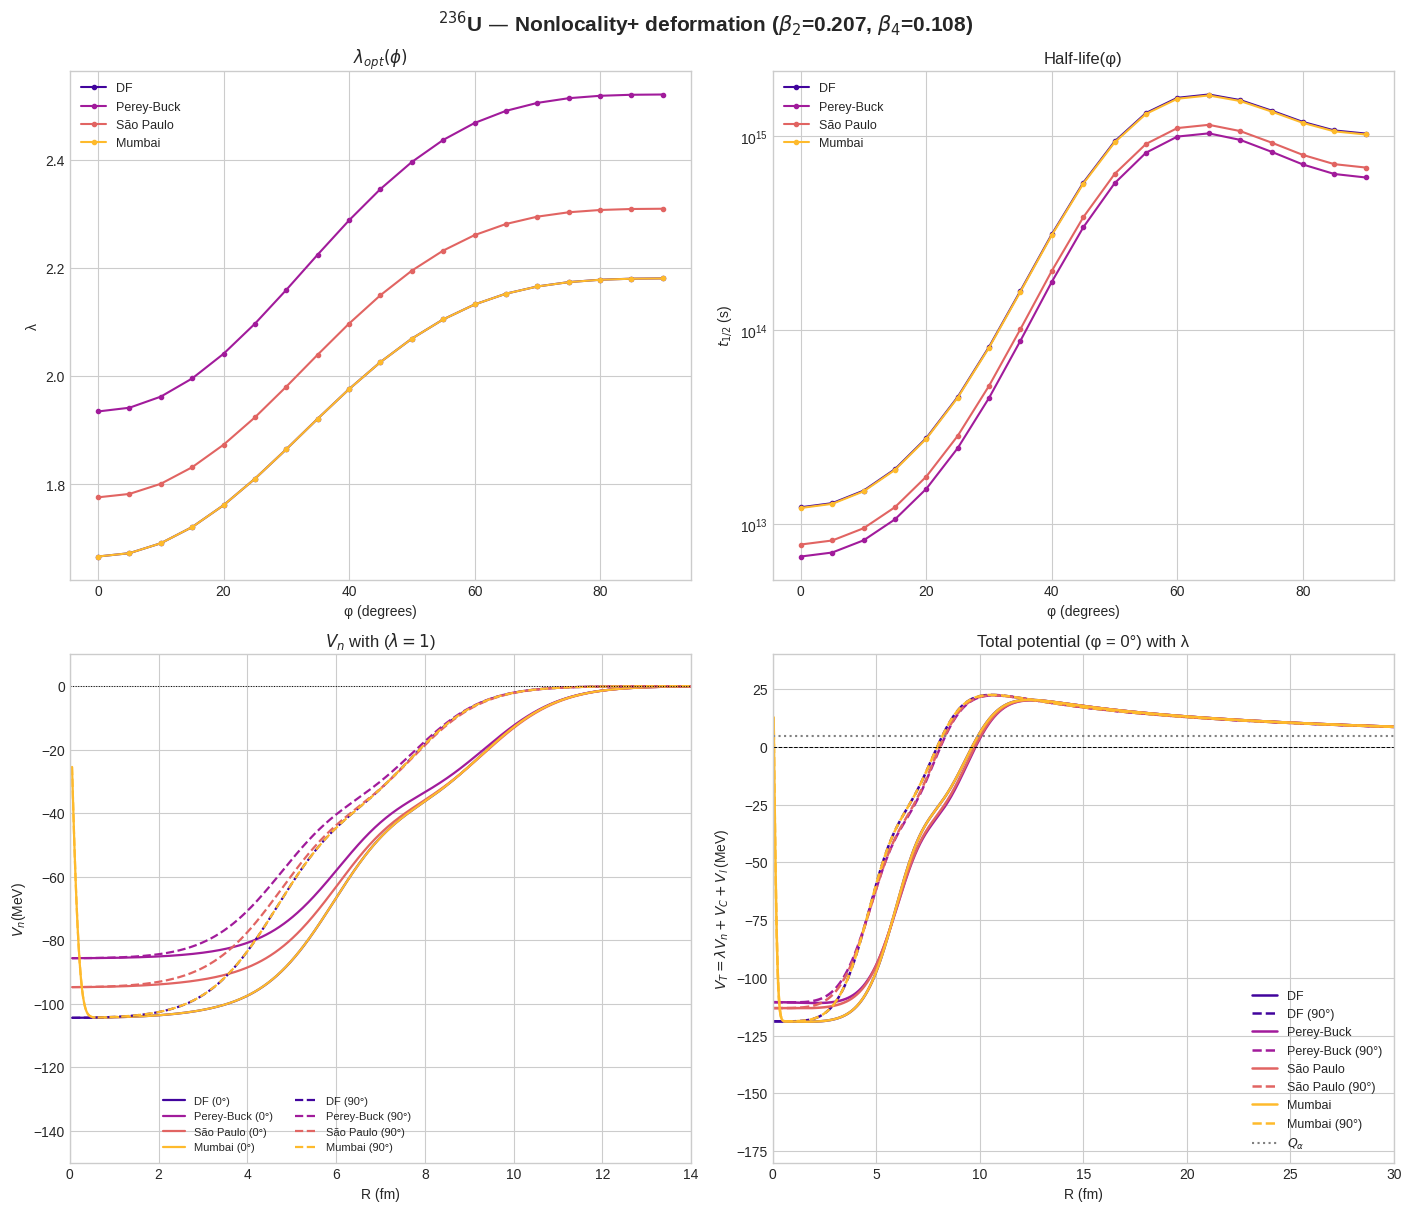

In [3]:
# With beta 2 and beta 4 are positive
"""
═══════════════════════════════════════════════════════════════════════════════
 FUSIÓN:  No-localidad (Double Folding / Perey-Buck / São Paulo / Mumbai)
          +  Deformación de la hija (beta2, beta4)  en decaimiento alfa
═══════════════════════════════════════════════════════════════════════════════

 Alfa   : esférica (densidad gaussiana)
 Hija   : Fermi deformada  ->  R(theta), a(theta)  con Y20, Y40
 Salida : lambda(phi), puntos de retorno, P, N, tau(phi) para los 4 modelos
          + vida media promediada angularmente

 NOTAS FÍSICAS IMPORTANTES (no es "solo sintaxis"):
 ------------------------------------------------------------------
 (1) Perey-Buck y São Paulo son transformaciones NO LINEALES en V.
     => se aplican al potencial nuclear TOTAL a phi fijo,
        NUNCA multipolo por multipolo.
 (2) Mumbai es LINEAL en V  => Mumbai(lam*V) = lam*Mumbai(V).
     Por eso para Mumbai da exactamente igual renormalizar antes o después.
 (3) São Paulo usa V_Coulomb en la exponencial: aquí se usa el
     V_Coulomb(R, phi) de la MISMA orientación.

 CAMBIOS NUMÉRICOS respecto a tus dos códigos:
 ------------------------------------------------------------------
 * j_L: se usa scipy.special.spherical_jn. Tus j2_f/j4_f tenían
   términos 105/x^5 que se rompen para k*r ~ 1e-5 (cancelación
   catastrófica). Ese era un bug latente en el código deformado.
 * theta: cuadratura Gauss-Legendre en u = cos(theta) (64 nodos)
   en vez de Simpson en theta. Más exacta y más barata.
 * Perey-Buck / São Paulo: se resuelven con la función W de Lambert
   (solución EXACTA y vectorizada) en vez de brentq punto por punto.
   Es la misma raíz física que daba tu brentq (rama principal, la que
   tiende a U -> U_bare cuando beta_nl -> 0).
 * Mumbai: se explota que la grilla R es uniforme  => el kernel es
   Toeplitz/Hankel y V((Ri+Rj)/2) vive en una semi-grilla.
   Se reduce de O(N^2) evaluaciones de spline a O(N) + gathers.
 * lambda: barrido grueso + brentq (en vez de 3000 puntos de barrido).
═══════════════════════════════════════════════════════════════════════════════
"""

import time
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from scipy.special import spherical_jn, lambertw


# ═════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════
NUCLEUS = dict(name="U-236", Z_d=90, A_d=232, Q=4.573, G=22, beta2=0.207, beta4=0.108)

# "after"  -> lambda multiplica el potencial YA transformado  (= tu código 1)
# "before" -> lambda renormaliza el folding desnudo y LUEGO se hace no-local
LAMBDA_MODE = "after"

MAKE_PLOTS = True

# --- grillas -----------------------------------------------------------------
N_R, R_MIN, R_MAX = 4000, 0.05, 100.0   # dR ~ 0.025 fm  (necesario para Mumbai)
N_K, K_MIN, K_MAX = 900, 1e-4, 25.0
N_r, r_MAX        = 601, 20.0           # densidad de la hija
N_U               = 64                  # nodos Gauss-Legendre en cos(theta)
N_PHI             = 19                  # orientaciones en [0, pi/2] (impar!)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTANTES
# ═════════════════════════════════════════════════════════════════════════════
Z_alpha, A_alpha = 2, 4
e2       = 1.44
a_0      = 0.54
alpha_g  = 0.7024                # ancho gaussiano de la alfa
x_g      = 7999 / 4              # interacción NN (M3Y-like, forma Yukawa doble)
y_g      = 2134 / 2.5
hbarc    = 197.327
hbar     = 6.582119569e-22       # MeV*s
m_n      = 931.494
L        = 4                     # momento angular del alfa
beta_nl  = 0.2161                  # RANGO DE NO-LOCALIDAD (Perey-Buck / Mumbai)

name  = NUCLEUS["name"]
Z_d   = NUCLEUS["Z_d"]
A_d   = NUCLEUS["A_d"]
Q     = NUCLEUS["Q"]
G     = NUCLEUS["G"]
beta2 = NUCLEUS["beta2"]
beta4 = NUCLEUS["beta4"]

R_0  = 1.07 * A_d ** (1 / 3)
mu   = (A_d * A_alpha) / (A_d + A_alpha) * m_n
B_qn = (G - L + 1) * (np.pi / 2)          # regla de Bohr-Sommerfeld
zpb  = (mu * beta_nl ** 2) / (2 * hbarc ** 2)
r3_C = (Z_alpha * Z_d * e2) / Q           # radio de Coulomb puro (referencia)


# ═════════════════════════════════════════════════════════════════════════════
#  GEOMETRÍA DEFORMADA DE LA HIJA
# ═════════════════════════════════════════════════════════════════════════════
def Y20(th):
    return 0.25 * np.sqrt(5 / np.pi) * (3 * np.cos(th) ** 2 - 1)


def Y40(th):
    c = np.cos(th)
    return (3 / 16) * np.sqrt(1 / np.pi) * (35 * c ** 4 - 30 * c ** 2 + 3)


def Y00(th):
    return np.full_like(np.asarray(th, dtype=float), np.sqrt(1 / (4 * np.pi)))


YLM = {0: Y00, 2: Y20, 4: Y40}


def R_f_theta(th):
    return R_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))


def a_f_theta(th):
    a_perp = a_0 * (1 + beta2 * Y20(th) + beta4 * Y40(th))
    c, s = np.cos(th), np.sin(th)
    gradR = (R_0 / R_f_theta(th)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * c * s
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * c ** 3 * s
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * c * s
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)


# ═════════════════════════════════════════════════════════════════════════════
#  GRILLAS
# ═════════════════════════════════════════════════════════════════════════════
R  = np.linspace(R_MIN, R_MAX, N_R)
dR = R[1] - R[0]
k  = np.linspace(K_MIN, K_MAX, N_K)
r  = np.linspace(0.0, r_MAX, N_r)

u_gl, w_gl = np.polynomial.legendre.leggauss(N_U)   # int_-1^1 du  == int sin(th) dth
theta_gl   = np.arccos(u_gl)

phi = np.linspace(0.0, np.pi / 2, N_PHI)

if dR > beta_nl / 4:
    print(f"  !! AVISO: dR = {dR:.4f} fm no resuelve beta_nl = {beta_nl} fm "
          f"(Mumbai será impreciso). Sube N_R.")


# ═════════════════════════════════════════════════════════════════════════════
#  DENSIDAD DEFORMADA Y SUS TRANSFORMADAS DE FOURIER MULTIPOLARES
# ═════════════════════════════════════════════════════════════════════════════
Rf_u = R_f_theta(theta_gl)
af_u = a_f_theta(theta_gl)

# fermi[r, u]
fermi = 1.0 / (1.0 + np.exp((r[:, None] - Rf_u[None, :]) / af_u[None, :]))

# Normalización:  int rho dV = 2*pi * int dr r^2 * int du fermi
I_geo   = 2 * np.pi * (simpson((r ** 2)[:, None] * fermi, x=r, axis=0) @ w_gl)
norm_N  = A_d / I_geo
norm_Cd = Z_d / I_geo


def fourier_rho2_L(Lm, norm, kchunk=64):
    """rho2_L(k) = 2pi * norm * int dr r^2 int du  j_L(kr) Y_L0(th) fermi(r,u)"""
    out = np.empty(N_K)
    W = w_gl * YLM[Lm](theta_gl)                     # (Nu,)
    r2f = (r ** 2)[:, None] * fermi                  # (Nr, Nu)
    for a0 in range(0, N_K, kchunk):
        kk = k[a0:a0 + kchunk]                       # (nk,)
        jl = spherical_jn(Lm, r[:, None] * kk[None, :])          # (Nr, nk)
        tmp = simpson(r2f[:, :, None] * jl[:, None, :], x=r, axis=0)   # (Nu, nk)
        out[a0:a0 + kchunk] = 2 * np.pi * norm * (W @ tmp)
    return out


print(f"\n>>> {name}   (Z_hija={Z_d}, A_hija={A_d}, Q={Q} MeV, "
      f"beta2={beta2}, beta4={beta4}, beta_nl={beta_nl} fm)")
t0 = time.time()
print("  [FT] densidad deformada de la hija (L = 0, 2, 4)...")
rho2_fn = {Lm: fourier_rho2_L(Lm, norm_N)  for Lm in (0, 2, 4)}
rho2_fc = {Lm: fourier_rho2_L(Lm, norm_Cd) for Lm in (0, 2, 4)}

# --- alfa (esférica, analítica) ----------------------------------------------
I_r1        = quad(lambda rr: rr ** 2 * np.exp(-alpha_g * rr ** 2), 0, 15)[0]
gauss_k     = np.exp(-k ** 2 / (4 * alpha_g))
rho1_fn     = 0.4228 * (np.pi / alpha_g) ** 1.5 * gauss_k
rho1_fc     = (Z_alpha / (4 * np.pi * I_r1)) * (np.pi / alpha_g) ** 1.5 * gauss_k


# ═════════════════════════════════════════════════════════════════════════════
#  POTENCIALES MULTIPOLARES  ->  V(R, phi)
# ═════════════════════════════════════════════════════════════════════════════
g_k = x_g / (k ** 2 + 4.0 ** 2) - y_g / (k ** 2 + 2.5 ** 2)


def V_nuclear_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fn * rho2L * k ** 2 * (4 * np.pi * g_k)
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


def V_coulomb_L(Lm, rho2L, pref, chunk=400):
    out = np.empty(N_R)
    w = pref * rho1_fc * rho2L
    for i0 in range(0, N_R, chunk):
        RR = R[i0:i0 + chunk][:, None]
        jl = spherical_jn(Lm, RR * k[None, :])
        out[i0:i0 + chunk] = (2 * e2 / np.pi) * simpson(w[None, :] * jl, x=k, axis=1)
    return out


print("  [V]  potenciales multipolares nuclear y Coulomb...")
pref_n = {0: 1 / np.sqrt(4 * np.pi),
          2: np.sqrt(5 / (4 * np.pi)),
          4: np.sqrt(9 / (4 * np.pi))}
pref_c = {Lm: 4 * np.pi * pref_n[Lm] for Lm in (0, 2, 4)}

V_NN_L = {Lm: V_nuclear_L(Lm, rho2_fn[Lm], pref_n[Lm]) for Lm in (0, 2, 4)}
V_C_L  = {Lm: V_coulomb_L(Lm, rho2_fc[Lm], pref_c[Lm]) for Lm in (0, 2, 4)}


def P2(p):
    return 0.5 * (3 * np.cos(p) ** 2 - 1)


def P4(p):
    c = np.cos(p)
    return (35 * c ** 4 - 30 * c ** 2 + 3) / 8


PL = np.vstack([np.ones_like(phi), P2(phi), P4(phi)])          # (3, Nphi)

V_Nuclear = (V_NN_L[0][:, None] * PL[0][None, :]
             + V_NN_L[2][:, None] * PL[1][None, :]
             + V_NN_L[4][:, None] * PL[2][None, :])            # (NR, Nphi)

V_Coulomb = (V_C_L[0][:, None] * PL[0][None, :]
             + V_C_L[2][:, None] * PL[1][None, :]
             + V_C_L[4][:, None] * PL[2][None, :])

V_cent = (hbarc ** 2 / (2 * mu)) * ((L + 0.5) ** 2 / R ** 2)   # (NR,)


# ═════════════════════════════════════════════════════════════════════════════
#  NO-LOCALIDAD
# ═════════════════════════════════════════════════════════════════════════════
def _lambert_local(V_bare, E_eff):
    """
    Resuelve   U * exp(zpb * (E_eff - U)) = V_bare   en la rama física.
        t = -zpb*U  ->  t e^t = -zpb * V_bare * exp(-zpb*E_eff)
        U = -W0(arg)/zpb
    Reproduce exactamente la raíz que buscaba tu brentq(-350, 100).
    """
    arg = -zpb * V_bare * np.exp(-zpb * E_eff)
    w = lambertw(arg, k=0)
    U = -np.real(w) / zpb
    bad = (np.abs(np.imag(w)) > 1e-8) | ~np.isfinite(U)
    return np.where(bad, V_bare, U)          # fallback: potencial desnudo


def perey_buck(V_bare):
    """U * exp(zpb*(Q - U)) = V_bare"""
    return _lambert_local(V_bare, Q)


def sao_paulo(V_bare, V_C_col):
    """U * exp(zpb*(Q - V_C - U)) = V_bare"""
    return _lambert_local(V_bare, Q - V_C_col)


# --- Mumbai: kernel gaussiano no local, explotando grilla uniforme ------------
_i = np.arange(N_R)
_H = R_MIN + 0.5 * dR * np.arange(2 * N_R - 1)                 # semi-grilla
_K1 = np.exp(-((np.arange(-(N_R - 1), N_R) * dR) ** 2) / beta_nl ** 2)   # dep. de i-j
_K2 = np.exp(-((2 * R_MIN + np.arange(2 * N_R - 1) * dR) ** 2) / beta_nl ** 2)  # i+j


def mumbai(V_col, chunk=256):
    """
    V_M(R) = 1/(sqrt(pi) beta) * int dR' V((R+R')/2) *
             [ exp(-(R-R')^2/beta^2) - exp(-(R+R')^2/beta^2) ]
    """
    spl = InterpolatedUnivariateSpline(R, V_col, k=3)
    Vh = spl(_H)                                    # V en la semi-grilla
    out = np.empty(N_R)
    for i0 in range(0, N_R, chunk):
        ii = _i[i0:i0 + chunk][:, None]
        s = ii + _i[None, :]                        # i+j
        d = ii - _i[None, :] + (N_R - 1)            # i-j desplazado
        ker = _K1[d] - _K2[s]
        out[i0:i0 + chunk] = simpson(Vh[s] * ker, x=R, axis=1)
    return out / (np.sqrt(np.pi) * beta_nl)


# ═════════════════════════════════════════════════════════════════════════════
#  CONSTRUCTOR DE POTENCIAL POR MODELO
# ═════════════════════════════════════════════════════════════════════════════
def make_builder(model, VNN_col, VC_col):
    """Devuelve  lam -> V_nuclear_local(R)  para la orientación dada."""
    if model == "DF":
        return lambda lam: lam * VNN_col

    if model == "Mumbai":                      # lineal: antes == después
        VM = mumbai(VNN_col)
        return lambda lam: lam * VM

    if model == "Perey-Buck":
        if LAMBDA_MODE == "after":
            U = perey_buck(VNN_col)
            return lambda lam: lam * U
        return lambda lam: perey_buck(lam * VNN_col)

    if model == "São Paulo":
        if LAMBDA_MODE == "after":
            U = sao_paulo(VNN_col, VC_col)
            return lambda lam: lam * U
        return lambda lam: sao_paulo(lam * VNN_col, VC_col)

    raise ValueError(model)


# ═════════════════════════════════════════════════════════════════════════════
#  BOHR-SOMMERFELD + WKB  PARA UNA ORIENTACIÓN
# ═════════════════════════════════════════════════════════════════════════════
def _spline_and_roots(builder, lam, VC_col):
    V = builder(lam) + VC_col + V_cent
    s = InterpolatedUnivariateSpline(R, Q - V, k=3)
    rts = s.roots()
    if len(rts) < 3:
        return None
    return s, rts[0], rts[1], rts[2]


def action_inner(builder, lam, VC_col):
    out = _spline_and_roots(builder, lam, VC_col)
    if out is None:
        return None
    s, r1, r2, _ = out
    I = quad(lambda x: np.sqrt(np.maximum((2 * mu / hbarc ** 2) * s(x), 0.0)),
             r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]
    return I


def solve_orientation(builder, VC_col, lam_lo=0.4, lam_hi=3.5, n_scan=30):
    """Busca lambda tal que S_interior(lambda) = B, y devuelve todo lo demás."""
    grid = np.linspace(lam_lo, lam_hi, n_scan)
    f = []
    for lam in grid:
        I = action_inner(builder, lam, VC_col)
        f.append(np.nan if I is None else I - B_qn)
    f = np.array(f)

    lam_opt = None
    ok = np.isfinite(f)
    for a, b in zip(range(n_scan - 1), range(1, n_scan)):
        if ok[a] and ok[b] and f[a] * f[b] < 0:
            lam_opt = brentq(
                lambda lm: action_inner(builder, lm, VC_col) - B_qn,
                grid[a], grid[b], xtol=1e-5)
            break
    if lam_opt is None:                       # no hubo cambio de signo
        if not ok.any():
            return None
        lam_opt = grid[np.nanargmin(np.abs(f))]

    out = _spline_and_roots(builder, lam_opt, VC_col)
    if out is None:
        return None
    s, r1, r2, r3 = out

    # V(r) - Q  =  -s(r)
    I_G = quad(lambda x: np.sqrt(np.maximum(-(2 * mu / hbarc ** 2) * s(x), 0.0)),
               r2, r3, limit=200, points=[r2, r3], epsabs=1e-4, epsrel=1e-4)[0]
    I_f = quad(lambda x: 1 / np.sqrt(np.abs((2 * mu / hbarc ** 2) * s(x))),
               r1, r2, limit=200, points=[r1, r2], epsabs=1e-4, epsrel=1e-4)[0]

    N_norm = 1.0 / I_f
    P = np.exp(-2 * I_G)
    Gamma = (hbarc ** 2 * P * N_norm) / (2 * mu)
    tau = (hbar * np.log(2)) / Gamma
    return dict(lam=lam_opt, r1=r1, r2=r2, r3=r3,
                P=P, N=N_norm, Gamma=Gamma, tau=tau)


# ═════════════════════════════════════════════════════════════════════════════
#  LOOP PRINCIPAL:  4 modelos  x  N_PHI orientaciones
# ═════════════════════════════════════════════════════════════════════════════
MODELOS = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]
resultados = {m: [] for m in MODELOS}

for m in MODELOS:
    print(f"  [WKB] {m} ...", end="", flush=True)
    for j in range(N_PHI):
        builder = make_builder(m, V_Nuclear[:, j], V_Coulomb[:, j])
        resultados[m].append(solve_orientation(builder, V_Coulomb[:, j]))
    print(" ok")

print(f"  (tiempo total: {time.time() - t0:.1f} s)")


# ═════════════════════════════════════════════════════════════════════════════
#  PROMEDIO ANGULAR
#  El alfa se emite en todas las orientaciones -> se promedia el ANCHO:
#      <Gamma> = int_0^{pi/2} Gamma(phi) sin(phi) dphi / int_0^{pi/2} sin(phi) dphi
#      T_1/2   = hbar ln2 / <Gamma>
# ═════════════════════════════════════════════════════════════════════════════
w_phi = np.sin(phi)
den = simpson(w_phi, x=phi)


def promedio(res_list):
    g = np.array([np.nan if r is None else r["Gamma"] for r in res_list])
    good = np.isfinite(g)
    if not good.any():
        return None
    g = np.where(good, g, 0.0)
    G_avg = simpson(g * w_phi, x=phi) / den
    return G_avg, (hbar * np.log(2)) / G_avg


# ═════════════════════════════════════════════════════════════════════════════
#  TABLAS
# ═════════════════════════════════════════════════════════════════════════════
sep = "=" * 118
print("\n" + sep)
print(f"{name}   —  DETALLE POR ORIENTACIÓN     (lambda aplicado: '{LAMBDA_MODE}')")
print(sep)
print(f"{'Modelo':<12} {'phi':>6} {'lambda':>8} {'r1':>8} {'r2':>8} {'r3':>8} "
      f"{'P':>12} {'N':>10} {'t1/2 (s)':>13}")
print("-" * 118)
for m in MODELOS:
    for j, res in enumerate(resultados[m]):
        if res is None:
            print(f"{m:<12} {np.degrees(phi[j]):6.1f} {'--- sin solución ---':>60}")
            continue
        print(f"{m:<12} {np.degrees(phi[j]):6.1f} {res['lam']:8.4f} "
              f"{res['r1']:8.3f} {res['r2']:8.3f} {res['r3']:8.3f} "
              f"{res['P']:12.3e} {res['N']:10.4f} {res['tau']:13.3e}")
    print("-" * 118)

print("\n" + sep)
print(f"{name}   —  RESUMEN PROMEDIADO ANGULARMENTE       "
      f"(r3 Coulomb puro = {r3_C:.2f} fm)")
print(sep)
print(f"{'Modelo':<12} {'<lambda>':>10} {'t1/2 (0°)':>13} {'t1/2 (90°)':>13} "
      f"{'<Gamma> (MeV)':>15} {'T1/2 <Gamma> (s)':>18}")
print("-" * 118)
for m in MODELOS:
    lams = np.array([r["lam"] for r in resultados[m] if r is not None])
    t0d = resultados[m][0]
    t90 = resultados[m][-1]
    pr = promedio(resultados[m])
    print(f"{m:<12} {lams.mean():10.4f} "
          f"{(t0d['tau'] if t0d else np.nan):13.3e} "
          f"{(t90['tau'] if t90 else np.nan):13.3e} "
          f"{(pr[0] if pr else np.nan):15.3e} "
          f"{(pr[1] if pr else np.nan):18.3e}")
print(sep + "\n")


# ═════════════════════════════════════════════════════════════════════════════
#  GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = dict(zip(MODELOS, plt.cm.plasma(np.linspace(0.1, 0.85, 4))))
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    fig.suptitle(rf"$^{{{A_d + 4}}}${name.split('-')[0]} — Nonlocality"
                 rf"+ deformation ($\beta_2$={beta2}, $\beta_4$={beta4})",
                 fontsize=15, fontweight='bold')

    for m in MODELOS:
        ph = np.degrees([phi[j] for j, r in enumerate(resultados[m]) if r])
        lm = [r["lam"] for r in resultados[m] if r]
        tt = [r["tau"] for r in resultados[m] if r]
        ax[0, 0].plot(ph, lm, '-o', ms=3, label=m, color=colors[m])
        ax[0, 1].semilogy(ph, tt, '-o', ms=3, label=m, color=colors[m])

    ax[0, 0].set(xlabel="φ (degrees)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
    ax[0, 1].set(xlabel="φ (degrees)", ylabel=r"$t_{1/2}$ (s)",
                 title="Half-life(φ)")
    for a in (ax[0, 0], ax[0, 1]):
        a.legend(frameon=False, fontsize=9)

    # potenciales nucleares locales-equivalentes en phi = 0 y 90
    for jj, ls, lbl in ((0, '-', '0°'), (N_PHI - 1, '--', '90°')):
        for m in MODELOS:
            bld = make_builder(m, V_Nuclear[:, jj], V_Coulomb[:, jj])
            ax[1, 0].plot(R, bld(1.0), ls, lw=1.6, color=colors[m],
                          label=f"{m} ({lbl})")
    ax[1, 0].set(xlabel="R (fm)", ylabel=r"$V_{n}$(MeV)", xlim=(0, 14), ylim=(-150, 10),
                 title=r"$V_{n}$ with ($\lambda=1$)")
    ax[1, 0].axhline(0, color='k', lw=0.7, ls=':')
    ax[1, 0].legend(fontsize=8, ncol=2, loc='lower center', bbox_to_anchor=(0.35, 0))

    # potencial total
    j0, j90 = 0, N_PHI - 1
    for m in MODELOS:
        res = resultados[m][0]
        if res is None:
            continue
        bld = make_builder(m, V_Nuclear[:, j0], V_Coulomb[:, j0])
        ax[1, 1].plot(R, bld(res["lam"]) + V_Coulomb[:, j0],
                      lw=1.8, color=colors[m], label=m)
        bld90 = make_builder(m, V_Nuclear[:, j90], V_Coulomb[:, j90])
        ax[1, 1].plot(R, bld90(res["lam"]) + V_Coulomb[:, j90],
                  lw=1.8, ls='--', color=colors[m], label=f"{m} (90°)")

    ax[1, 1].axhline(Q, color='gray', ls=':', lw=1.5, label=r"$Q_\alpha$")
    ax[1, 1].axhline(0, color='k', lw=0.7, ls='--')
    ax[1, 1].set(xlabel="R (fm)", ylabel=r"$V_{T}=λV_{n}+V_{C}+V_{l}\,$(MeV)", xlim=(0, 30), ylim=(-180, 40),
                 title="Total potential (φ = 0°) with λ")
    ax[1, 1].legend(fontsize=9, frameon=False)
    plt.savefig('U-221-nonlocal-deformation.png')
    plt.show()